#  Phase 0 — Setup & project structure

## Notebook Sections

This notebook is organized as a complete forecasting workflow for the Store Sales time series competition. Each section builds from project framing through data understanding, modeling, evaluation, submission, and deployment planning.

### Problem overview

Define the forecasting objective, target variable, competition context, evaluation metric, business value, and key constraints that shape the modeling approach.

### Data description

Summarize the available datasets, important columns, date ranges, store and product family dimensions, external signals, and known data quality considerations.

### EDA

Explore sales patterns, seasonality, trends, holidays, promotions, oil prices, store-level behavior, product-family behavior, missing values, and outliers.

### Feature engineering

Create calendar features, lag features, rolling statistics, promotion signals, holiday indicators, store metadata features, and leakage-safe transformations.

### Validation strategy

Use time-aware validation splits that mimic the competition forecast horizon, prevent future leakage, and compare models using consistent RMSLE-style evaluation.

### Baseline model

Build simple benchmark forecasts, such as historical averages or seasonal naive predictions, to establish a minimum performance bar for later models.

### Gradient boosting models

Train and compare tree-based boosting models using engineered features, careful validation, and model-specific tuning for tabular time series forecasting.

### Error analysis

Inspect residuals by date, store, family, promotion status, holidays, and sales volume to identify systematic weaknesses and guide refinements.

### Submission

Generate final test predictions, apply post-processing where appropriate, validate the submission format, and save the output file for Kaggle upload.

### Deployment plan

Document how the forecasting pipeline could be refreshed, monitored, versioned, and deployed for repeated business use beyond the competition notebook.

### Optional transformer bonus

Outline an optional deep learning experiment using attention or transformer-style sequence modeling, including when it may or may not outperform boosted trees.

#  Phase 1 — Data Integration & EDA

## Objective

Understand the structure, trends, seasonality, missing values, and external events in the data.

## 1.1 Load and inspect data

### Setup paths and imports

In [10]:
from pathlib import Path
import subprocess
import zipfile

import numpy as np
import pandas as pd

pd.set_option("display.max_columns", 100)
pd.set_option("display.max_rows", 100)


def find_project_root(start: Path | None = None) -> Path:
    """Find the repository root from either the notebook or project directory."""
    start = Path.cwd() if start is None else Path(start).resolve()
    for path in [start, *start.parents]:
        if (path / "data" / "raw").exists() and (path / "notebooks").exists():
            return path
    raise RuntimeError("Could not find project root containing data/raw and notebooks.")


PROJECT_ROOT = find_project_root()
RAW_DATA_DIR = PROJECT_ROOT / "data" / "raw"

PROJECT_ROOT, RAW_DATA_DIR

(WindowsPath('f:/Coding/Data_Science/store-sales-time-series-forecasting'),
 WindowsPath('f:/Coding/Data_Science/store-sales-time-series-forecasting/data/raw'))

### Load all CSV files

In [11]:
expected_files = {
    "train": "train.csv",
    "test": "test.csv",
    "stores": "stores.csv",
    "oil": "oil.csv",
    "holidays_events": "holidays_events.csv",
    "transactions": "transactions.csv",
    "sample_submission": "sample_submission.csv",
}

"""That snippet is doing a data integrity check before the notebook proceeds."""
missing_files = [filename for filename in expected_files.values() if not (RAW_DATA_DIR / filename).exists()]
if missing_files:
    raise FileNotFoundError(
        "Missing raw data files: " + ", ".join(missing_files) + f". Expected them in {RAW_DATA_DIR}"
    )

data = {
    name: pd.read_csv(RAW_DATA_DIR / filename)
    for name, filename in expected_files.items()
}

loaded_files = pd.DataFrame(
    [
        {
            "dataset": name,
            "file": expected_files[name],
            "rows": df.shape[0],
            "columns": df.shape[1],
        }
        for name, df in data.items()
    ]
)

loaded_files

,dataset,file,rows,columns
0,train,train.csv,3000888,6
1,test,test.csv,28512,5
2,stores,stores.csv,54,5
3,oil,oil.csv,1218,2
4,holidays_events,holidays_events.csv,350,6
5,transactions,transactions.csv,83488,3
6,sample_submission,sample_submission.csv,28512,2


### Check shapes, columns, dtypes, and missing values

In [12]:
dataset_overview = pd.DataFrame(
    [
        {
            "dataset": name,
            "rows": df.shape[0],
            "columns": df.shape[1],
            "duplicate_rows": int(df.duplicated().sum()),
            "missing_values": int(df.isna().sum().sum()),
        }
        for name, df in data.items()
    ]
).sort_values("dataset")

dataset_overview

,dataset,rows,columns,duplicate_rows,missing_values
4,holidays_events,350,6,0,0
3,oil,1218,2,0,43
6,sample_submission,28512,2,0,0
2,stores,54,5,0,0
1,test,28512,5,0,0
0,train,3000888,6,0,0
5,transactions,83488,3,0,0


In [13]:
def column_profile(df: pd.DataFrame, dataset_name: str) -> pd.DataFrame:
    return pd.DataFrame(
        {
            "dataset": dataset_name,
            "column": df.columns,
            "dtype": df.dtypes.astype(str).values,
            "missing": df.isna().sum().values,
            "missing_pct": (df.isna().mean().values * 100).round(2),
            "unique_values": df.nunique(dropna=True).values,
        }
    )


column_profiles = pd.concat(
    [column_profile(df, name) for name, df in data.items()],
    ignore_index=True,
)

column_profiles

,dataset,column,dtype,missing,missing_pct,unique_values
0,train,id,int64,0,0.00,3000888
1,train,date,object,0,0.00,1684
2,train,store_nbr,int64,0,0.00,54
3,train,family,object,0,0.00,33
4,train,sales,float64,0,0.00,379610
5,train,onpromotion,int64,0,0.00,362
6,test,id,int64,0,0.00,28512
7,test,date,object,0,0.00,16
8,test,store_nbr,int64,0,0.00,54
9,test,family,object,0,0.00,33


### Convert all date columns to datetime

In [14]:
date_columns = {}

for name, df in data.items():
    cols = [col for col in df.columns if "date" in col.lower()]
    date_columns[name] = cols
    for col in cols:
        df[col] = pd.to_datetime(df[col], errors="coerce")

converted_date_columns = pd.DataFrame(
    [
        {
            "dataset": name,
            "date_columns": ", ".join(cols) if cols else "None",
        }
        for name, cols in date_columns.items()
    ]
)

converted_date_columns

,dataset,date_columns
0,train,date
1,test,date
2,stores,None
3,oil,date
4,holidays_events,date
5,transactions,date
6,sample_submission,None


### Inspect date ranges for train and test

In [15]:
date_range_rows = []

for name in ["train", "test", "oil", "holidays_events", "transactions"]:
    df = data[name]
    if "date" not in df.columns:
        continue
    date_range_rows.append(
        {
            "dataset": name,
            "min_date": df["date"].min(),
            "max_date": df["date"].max(),
            "unique_dates": df["date"].nunique(),
            "missing_dates": int(df["date"].isna().sum()),
        }
    )

date_ranges = pd.DataFrame(date_range_rows)
date_ranges

,dataset,min_date,max_date,unique_dates,missing_dates
0,train,2013-01-01,2017-08-15,1684,0
1,test,2017-08-16,2017-08-31,16,0
2,oil,2013-01-01,2017-08-31,1218,0
3,holidays_events,2012-03-02,2017-12-26,312,0
4,transactions,2013-01-01,2017-08-15,1682,0


### Confirm the forecast horizon in the test set

In [16]:
test_dates = data["test"]["date"].dropna().sort_values().unique()

forecast_horizon = pd.DataFrame(
    [
        {
            "test_start": test_dates.min(),
            "test_end": test_dates.max(),
            "forecast_days": len(test_dates),
            "rows_per_date_min": data["test"].groupby("date").size().min(),
            "rows_per_date_max": data["test"].groupby("date").size().max(),
        }
    ]
)

forecast_horizon

,test_start,test_end,forecast_days,rows_per_date_min,rows_per_date_max
0,2017-08-16,2017-08-31,16,1782,1782


### Check uniqueness of key combinations

In [17]:
def uniqueness_check(df: pd.DataFrame, dataset_name: str, columns: list[str]) -> dict:
    available_columns = [col for col in columns if col in df.columns]
    if len(available_columns) != len(columns):
        return {
            "dataset": dataset_name,
            "key": ", ".join(columns),
            "available": False,
            "rows": len(df),
            "unique_keys": np.nan,
            "duplicate_keys": np.nan,
        }

    duplicate_count = int(df.duplicated(subset=columns).sum())
    return {
        "dataset": dataset_name,
        "key": ", ".join(columns),
        "available": True,
        "rows": len(df),
        "unique_keys": int(df[columns].drop_duplicates().shape[0]),
        "duplicate_keys": duplicate_count,
    }


uniqueness_results = pd.DataFrame(
    [
        uniqueness_check(data["train"], "train", ["id"]),
        uniqueness_check(data["test"], "test", ["id"]),
        uniqueness_check(data["sample_submission"], "sample_submission", ["id"]),
        uniqueness_check(data["train"], "train", ["date", "store_nbr", "family"]),
        uniqueness_check(data["test"], "test", ["date", "store_nbr", "family"]),
    ]
)

uniqueness_results

,dataset,key,available,rows,unique_keys,duplicate_keys
0,train,id,True,3000888,3000888,0
1,test,id,True,28512,28512,0
2,sample_submission,id,True,28512,28512,0
3,train,"date, store_nbr, family",True,3000888,3000888,0
4,test,"date, store_nbr, family",True,28512,28512,0


In [18]:
key_columns = ["date", "store_nbr", "family"]

duplicate_samples = {
    name: df.loc[df.duplicated(subset=key_columns, keep=False), ["id", *key_columns]].head(10)
    for name, df in {"train": data["train"], "test": data["test"]}.items()
}

duplicate_samples

{'train': Empty DataFrame
 Columns: [id, date, store_nbr, family]
 Index: [],
 'test': Empty DataFrame
 Columns: [id, date, store_nbr, family]
 Index: []}

## 1.2 Relational mapping

- [ ] Merge `train.csv` with `stores.csv`
- [ ] Merge oil prices by date
- [ ] Prepare holiday data carefully before merging
- [ ] Inspect `transactions.csv` and decide whether to use it
  - Use for EDA if it is unavailable in the test period
  - Avoid using future-only information as model input
- [ ] Create a data dictionary table in markdown
  - Column name
  - Source file
  - Meaning
  - Modeling use

### Merge store, oil, holiday, and transaction data

In [19]:
stores = data["stores"].copy()
oil = data["oil"].copy().sort_values("date")
holidays = data["holidays_events"].copy()
transactions = data["transactions"].copy()

train_base = data["train"].copy()
test_base = data["test"].copy()

train_store = train_base.merge(stores, on="store_nbr", how="left", validate="many_to_one")
test_store = test_base.merge(stores, on="store_nbr", how="left", validate="many_to_one")

train_store_oil = train_store.merge(oil, on="date", how="left", validate="many_to_one")
test_store_oil = test_store.merge(oil, on="date", how="left", validate="many_to_one")

merge_quality = pd.DataFrame(
    [
        {
            "dataset": "train_store_oil",
            "rows": len(train_store_oil),
            "missing_store_rows": int(train_store_oil["city"].isna().sum()),
            "missing_oil_rows": int(train_store_oil["dcoilwtico"].isna().sum()),
        },
        {
            "dataset": "test_store_oil",
            "rows": len(test_store_oil),
            "missing_store_rows": int(test_store_oil["city"].isna().sum()),
            "missing_oil_rows": int(test_store_oil["dcoilwtico"].isna().sum()),
        },
    ]
)

merge_quality

,dataset,rows,missing_store_rows,missing_oil_rows
0,train_store_oil,3000888,0,928422
1,test_store_oil,28512,0,7128


In [20]:
holidays_clean = holidays.copy()
holidays_clean["transferred"] = holidays_clean["transferred"].fillna(False).astype(bool)
holidays_clean["is_work_day"] = holidays_clean["type"].eq("Work Day")
holidays_clean["is_bridge"] = holidays_clean["type"].eq("Bridge")
holidays_clean["is_event"] = holidays_clean["type"].eq("Event")
holidays_clean["is_active_holiday"] = ~holidays_clean["transferred"] & ~holidays_clean["is_work_day"]

active_holidays = holidays_clean.loc[holidays_clean["is_active_holiday"]].copy()

national_holidays = (
    active_holidays.loc[active_holidays["locale"].eq("National")]
    .groupby("date", as_index=False)
    .agg(
        national_holiday_count=("description", "nunique"),
        national_holiday_names=("description", lambda values: "; ".join(sorted(set(values)))),
    )
)

regional_holidays = (
    active_holidays.loc[active_holidays["locale"].eq("Regional")]
    .rename(columns={"locale_name": "state"})
    .groupby(["date", "state"], as_index=False)
    .agg(
        regional_holiday_count=("description", "nunique"),
        regional_holiday_names=("description", lambda values: "; ".join(sorted(set(values)))),
    )
)

local_holidays = (
    active_holidays.loc[active_holidays["locale"].eq("Local")]
    .rename(columns={"locale_name": "city"})
    .groupby(["date", "city"], as_index=False)
    .agg(
        local_holiday_count=("description", "nunique"),
        local_holiday_names=("description", lambda values: "; ".join(sorted(set(values)))),
    )
)

holiday_summary = holidays_clean.groupby(["locale", "type", "transferred"], as_index=False).size()
holiday_summary

,locale,type,transferred,size
0,Local,Additional,False,11
1,Local,Holiday,False,133
2,Local,Holiday,True,4
3,Local,Transfer,False,4
4,National,Additional,False,40
5,National,Bridge,False,5
6,National,Event,False,56
7,National,Holiday,False,52
8,National,Holiday,True,8
9,National,Transfer,False,8


In [21]:
def add_holiday_features(df: pd.DataFrame) -> pd.DataFrame:
    enriched = df.merge(national_holidays, on="date", how="left")
    enriched = enriched.merge(regional_holidays, on=["date", "state"], how="left")
    enriched = enriched.merge(local_holidays, on=["date", "city"], how="left")

    count_cols = ["national_holiday_count", "regional_holiday_count", "local_holiday_count"]
    name_cols = ["national_holiday_names", "regional_holiday_names", "local_holiday_names"]
    enriched[count_cols] = enriched[count_cols].fillna(0).astype(int)
    enriched[name_cols] = enriched[name_cols].fillna("")
    enriched["has_holiday"] = enriched[count_cols].sum(axis=1).gt(0)
    return enriched


train_enriched = add_holiday_features(train_store_oil)
test_enriched = add_holiday_features(test_store_oil)

transactions_by_store_date = transactions.rename(columns={"transactions": "store_transactions"})
train_eda = train_enriched.merge(
    transactions_by_store_date,
    on=["date", "store_nbr"],
    how="left",
    validate="many_to_one",
)

test_transaction_overlap = transactions["date"].between(
    test_base["date"].min(),
    test_base["date"].max(),
).any()

transaction_decision = pd.DataFrame(
    [
        {
            "available_in_test_period": bool(test_transaction_overlap),
            "min_transaction_date": transactions["date"].min(),
            "max_transaction_date": transactions["date"].max(),
            "modeling_decision": "Use for EDA only; do not use as a direct model input if unavailable for future test dates.",
        }
    ]
)

transaction_decision

,available_in_test_period,min_transaction_date,max_transaction_date,modeling_decision
0,False,2013-01-01,2017-08-15,Use for EDA only; do not use as a direct model...


### Data dictionary

In [22]:
data_dictionary = pd.DataFrame(
    [
        ("id", "train/test/sample_submission", "Unique row identifier", "Join predictions to submission rows"),
        ("date", "train/test/oil/holidays/transactions", "Calendar date", "Time index, merges, calendar features"),
        ("store_nbr", "train/test/stores/transactions", "Store identifier", "Store-level grouping and joins"),
        ("family", "train/test", "Product family", "Main product hierarchy feature"),
        ("sales", "train", "Unit sales target", "Target variable"),
        ("onpromotion", "train/test", "Number of promoted items", "Known future promotional feature"),
        ("city", "stores", "Store city", "Local holiday merge and location feature"),
        ("state", "stores", "Store state", "Regional holiday merge and location feature"),
        ("type", "stores/holidays", "Store type or holiday type", "Categorical feature / holiday interpretation"),
        ("cluster", "stores", "Store cluster group", "Store similarity feature"),
        ("dcoilwtico", "oil", "Daily oil price", "External economic signal after leakage-safe imputation"),
        ("locale", "holidays_events", "Holiday scope", "Separate national, regional, and local holiday effects"),
        ("locale_name", "holidays_events", "Holiday location name", "Match local/regional holidays to stores"),
        ("description", "holidays_events", "Holiday/event description", "Event analysis and special flags"),
        ("transferred", "holidays_events", "Whether the holiday was moved", "Avoid treating transferred original dates as active holidays"),
        ("store_transactions", "transactions", "Daily transactions by store", "EDA only unless future values are available"),
    ],
    columns=["Column name", "Source file", "Meaning", "Modeling use"],
)

data_dictionary

,Column name,Source file,Meaning,Modeling use
0,id,train/test/sample_submission,Unique row identifier,Join predictions to submission rows
1,date,train/test/oil/holidays/transactions,Calendar date,"Time index, merges, calendar features"
2,store_nbr,train/test/stores/transactions,Store identifier,Store-level grouping and joins
3,family,train/test,Product family,Main product hierarchy feature
4,sales,train,Unit sales target,Target variable
5,onpromotion,train/test,Number of promoted items,Known future promotional feature
6,city,stores,Store city,Local holiday merge and location feature
7,state,stores,Store state,Regional holiday merge and location feature
8,type,stores/holidays,Store type or holiday type,Categorical feature / holiday interpretation
9,cluster,stores,Store cluster group,Store similarity feature


## 1.3 Target analysis

- [ ] Plot total sales over time
- [ ] Plot sales by year and month
- [ ] Plot sales by day of week
- [ ] Plot sales by store type or cluster
- [ ] Plot top product families by total sales
- [ ] Identify product families with frequent zero sales
- [ ] Check whether sales have strong trend over time
- [ ] Check whether sales spike on weekends, paydays, holidays, or month-end

### Target behavior plots and summaries

In [23]:
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_theme(style="whitegrid", context="notebook")

sales_daily = (
    train_eda.groupby("date", as_index=False)
    .agg(total_sales=("sales", "sum"), total_promo=("onpromotion", "sum"))
)
sales_daily["year"] = sales_daily["date"].dt.year
sales_daily["month"] = sales_daily["date"].dt.month
sales_daily["day_of_week"] = sales_daily["date"].dt.day_name()
sales_daily["is_weekend"] = sales_daily["date"].dt.dayofweek.ge(5)
sales_daily["is_month_end"] = sales_daily["date"].dt.is_month_end
sales_daily["is_payday"] = sales_daily["date"].dt.day.isin([15]) | sales_daily["is_month_end"]
sales_daily["rolling_28d_sales"] = sales_daily["total_sales"].rolling(28, min_periods=7).mean()

sales_daily.head()

,date,total_sales,total_promo,year,month,day_of_week,is_weekend,is_month_end,is_payday,rolling_28d_sales
0,2013-01-01,2511.618999,0,2013,1,Tuesday,False,False,False,NaN
1,2013-01-02,496092.417944,0,2013,1,Wednesday,False,False,False,NaN
2,2013-01-03,361461.231124,0,2013,1,Thursday,False,False,False,NaN
3,2013-01-04,354459.677093,0,2013,1,Friday,False,False,False,NaN
4,2013-01-05,477350.121229,0,2013,1,Saturday,True,False,False,NaN


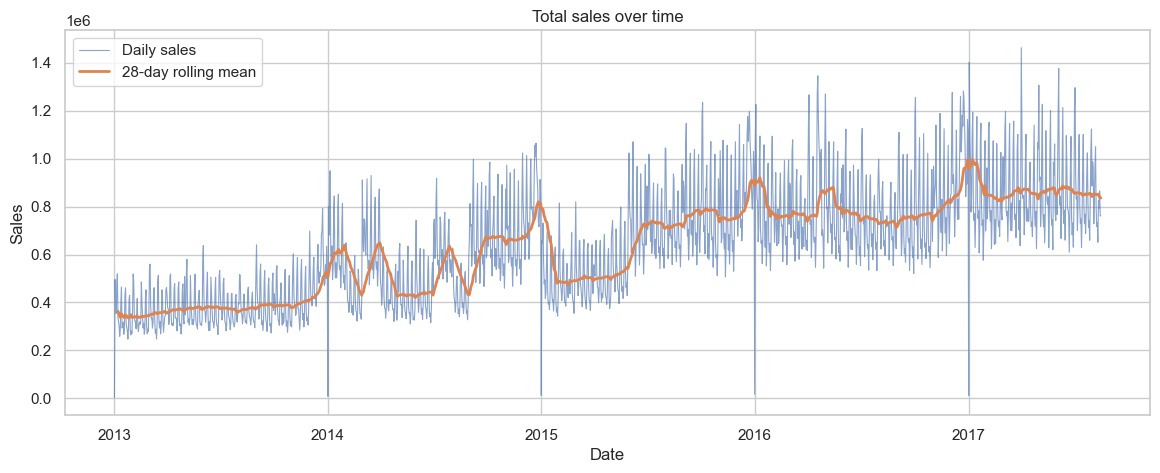

In [24]:
fig, ax = plt.subplots(figsize=(14, 5))
ax.plot(sales_daily["date"], sales_daily["total_sales"], linewidth=0.8, alpha=0.65, label="Daily sales")
ax.plot(sales_daily["date"], sales_daily["rolling_28d_sales"], linewidth=2, label="28-day rolling mean")
ax.set_title("Total sales over time")
ax.set_xlabel("Date")
ax.set_ylabel("Sales")
ax.legend()
plt.show()

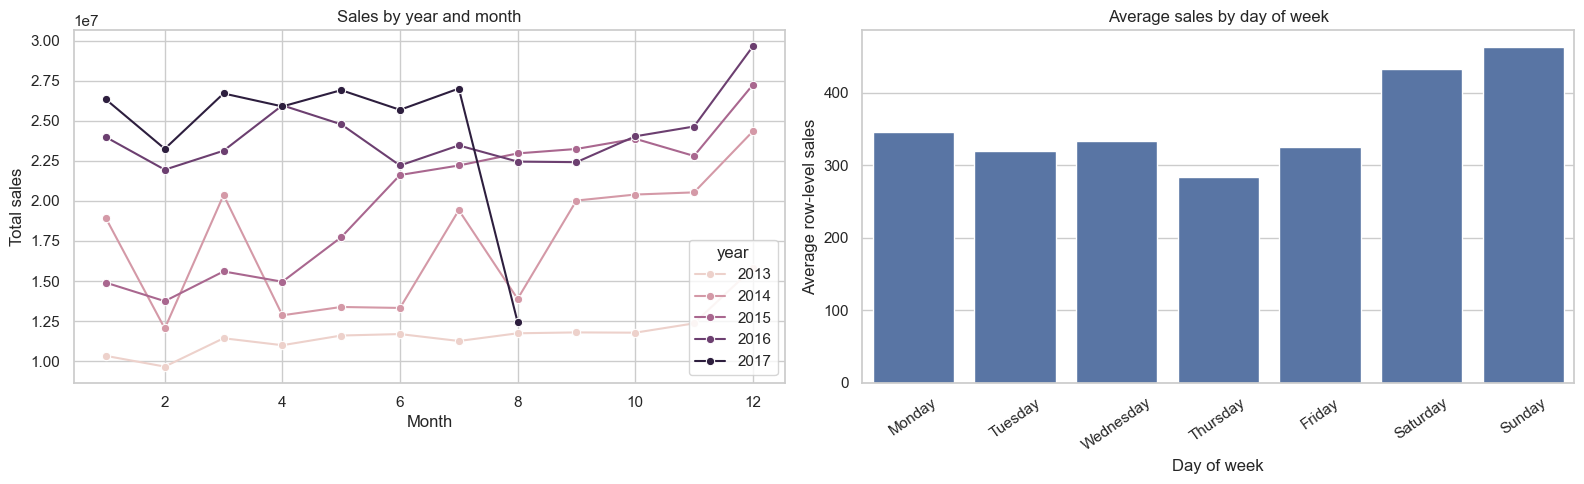

In [25]:
monthly_sales = (
    train_eda.assign(year=lambda df: df["date"].dt.year, month=lambda df: df["date"].dt.month)
    .groupby(["year", "month"], as_index=False)
    .agg(total_sales=("sales", "sum"))
)

dow_order = ["Monday", "Tuesday", "Wednesday", "Thursday", "Friday", "Saturday", "Sunday"]
dow_sales = (
    train_eda.assign(day_of_week=lambda df: pd.Categorical(df["date"].dt.day_name(), categories=dow_order, ordered=True))
    .groupby("day_of_week", observed=True, as_index=False)
    .agg(avg_sales=("sales", "mean"), total_sales=("sales", "sum"))
)

fig, axes = plt.subplots(1, 2, figsize=(16, 5))
sns.lineplot(data=monthly_sales, x="month", y="total_sales", hue="year", marker="o", ax=axes[0])
axes[0].set_title("Sales by year and month")
axes[0].set_xlabel("Month")
axes[0].set_ylabel("Total sales")

sns.barplot(data=dow_sales, x="day_of_week", y="avg_sales", ax=axes[1])
axes[1].set_title("Average sales by day of week")
axes[1].set_xlabel("Day of week")
axes[1].set_ylabel("Average row-level sales")
axes[1].tick_params(axis="x", rotation=35)

plt.tight_layout()
plt.show()

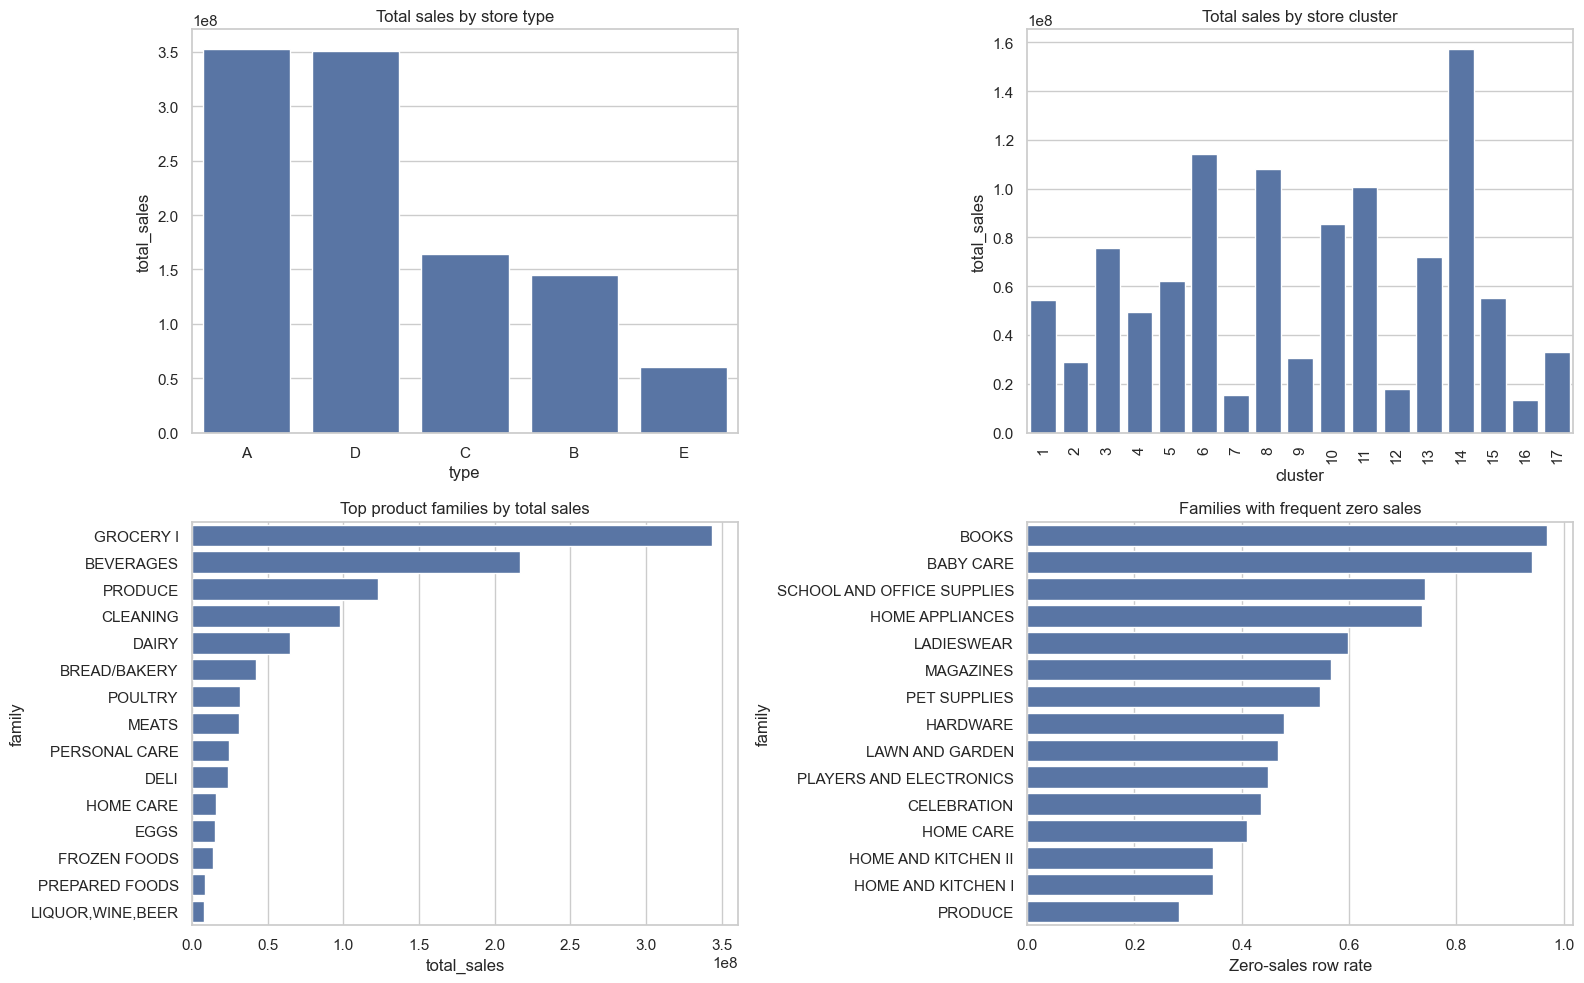

,family,total_sales,zero_sales_rate
4,BOOKS,6.438000e+03,0.969550
1,BABY CARE,1.005100e+04,0.941310
31,SCHOOL AND OFFICE SUPPLIES,2.693160e+05,0.740829
17,HOME APPLIANCES,4.160100e+04,0.735176
19,LADIESWEAR,6.511590e+05,0.598465
23,MAGAZINES,2.663590e+05,0.565387
26,PET SUPPLIES,3.565840e+05,0.546153
14,HARDWARE,1.034700e+05,0.478622
20,LAWN AND GARDEN,5.488420e+05,0.467846
27,PLAYERS AND ELECTRONICS,5.626080e+05,0.448865


In [26]:
store_type_sales = (
    train_eda.groupby("type", as_index=False)
    .agg(total_sales=("sales", "sum"), avg_sales=("sales", "mean"), rows=("sales", "size"))
    .sort_values("total_sales", ascending=False)
)

cluster_sales = (
    train_eda.groupby("cluster", as_index=False)
    .agg(total_sales=("sales", "sum"), avg_sales=("sales", "mean"), rows=("sales", "size"))
    .sort_values("cluster")
)

top_families = (
    train_eda.groupby("family", as_index=False)
    .agg(total_sales=("sales", "sum"), zero_sales_rate=("sales", lambda s: s.eq(0).mean()))
    .sort_values("total_sales", ascending=False)
)

zero_sales_families = top_families.sort_values("zero_sales_rate", ascending=False)

fig, axes = plt.subplots(2, 2, figsize=(16, 10))
sns.barplot(data=store_type_sales, x="type", y="total_sales", ax=axes[0, 0])
axes[0, 0].set_title("Total sales by store type")

sns.barplot(data=cluster_sales, x="cluster", y="total_sales", ax=axes[0, 1])
axes[0, 1].set_title("Total sales by store cluster")
axes[0, 1].tick_params(axis="x", rotation=90)

sns.barplot(data=top_families.head(15), y="family", x="total_sales", ax=axes[1, 0])
axes[1, 0].set_title("Top product families by total sales")

sns.barplot(data=zero_sales_families.head(15), y="family", x="zero_sales_rate", ax=axes[1, 1])
axes[1, 1].set_title("Families with frequent zero sales")
axes[1, 1].set_xlabel("Zero-sales row rate")

plt.tight_layout()
plt.show()

zero_sales_families.head(15)

In [27]:
daily_holiday_flags = (
    train_eda.groupby("date", as_index=False)
    .agg(has_holiday=("has_holiday", "max"))
)

spike_features = sales_daily.merge(daily_holiday_flags, on="date", how="left")
spike_features["has_holiday"] = spike_features["has_holiday"].fillna(False)
spike_features["period"] = np.select(
    [
        spike_features["has_holiday"],
        spike_features["is_weekend"],
        spike_features["is_payday"],
        spike_features["is_month_end"],
    ],
    ["holiday", "weekend", "payday", "month_end"],
    default="regular_day",
)

spike_summary = (
    spike_features.groupby("period", as_index=False)
    .agg(
        days=("date", "nunique"),
        avg_total_sales=("total_sales", "mean"),
        median_total_sales=("total_sales", "median"),
    )
    .sort_values("avg_total_sales", ascending=False)
)

trend_summary = pd.DataFrame(
    [
        {
            "first_90d_avg_sales": sales_daily.head(90)["total_sales"].mean(),
            "last_90d_avg_sales": sales_daily.tail(90)["total_sales"].mean(),
            "last_vs_first_ratio": sales_daily.tail(90)["total_sales"].mean() / sales_daily.head(90)["total_sales"].mean(),
        }
    ]
)

spike_summary, trend_summary

(        period  days  avg_total_sales  median_total_sales
 3      weekend   414    798485.758397       839771.205985
 0      holiday   239    701312.885857       689746.212316
 1       payday    69    578178.749155       624797.469491
 2  regular_day   962    556719.059060       572649.244377,
    first_90d_avg_sales  last_90d_avg_sales  last_vs_first_ratio
 0        349056.461687        855464.89298             2.450792)

## 1.4 External shocks and holidays

- [ ] Locate earthquake-related events in `holidays_events.csv`
- [ ] Plot sales around the 2016 earthquake period
- [ ] Compare sales before, during, and after major holidays
- [ ] Separate national, regional, and local holidays
- [ ] Inspect transferred holidays, bridge days, and work days

### Earthquake, holiday, and special-day analysis

In [28]:
earthquake_events = holidays_clean.loc[
    holidays_clean["description"].str.contains("terremoto|earthquake", case=False, na=False)
].sort_values("date")

earthquake_events

,date,type,locale,locale_name,description,transferred,is_work_day,is_bridge,is_event,is_active_holiday
219,2016-04-16,Event,National,Ecuador,Terremoto Manabi,False,False,False,True,True
220,2016-04-17,Event,National,Ecuador,Terremoto Manabi+1,False,False,False,True,True
221,2016-04-18,Event,National,Ecuador,Terremoto Manabi+2,False,False,False,True,True
222,2016-04-19,Event,National,Ecuador,Terremoto Manabi+3,False,False,False,True,True
223,2016-04-20,Event,National,Ecuador,Terremoto Manabi+4,False,False,False,True,True
225,2016-04-21,Event,National,Ecuador,Terremoto Manabi+5,False,False,False,True,True
226,2016-04-22,Event,National,Ecuador,Terremoto Manabi+6,False,False,False,True,True
227,2016-04-23,Event,National,Ecuador,Terremoto Manabi+7,False,False,False,True,True
228,2016-04-24,Event,National,Ecuador,Terremoto Manabi+8,False,False,False,True,True
229,2016-04-25,Event,National,Ecuador,Terremoto Manabi+9,False,False,False,True,True


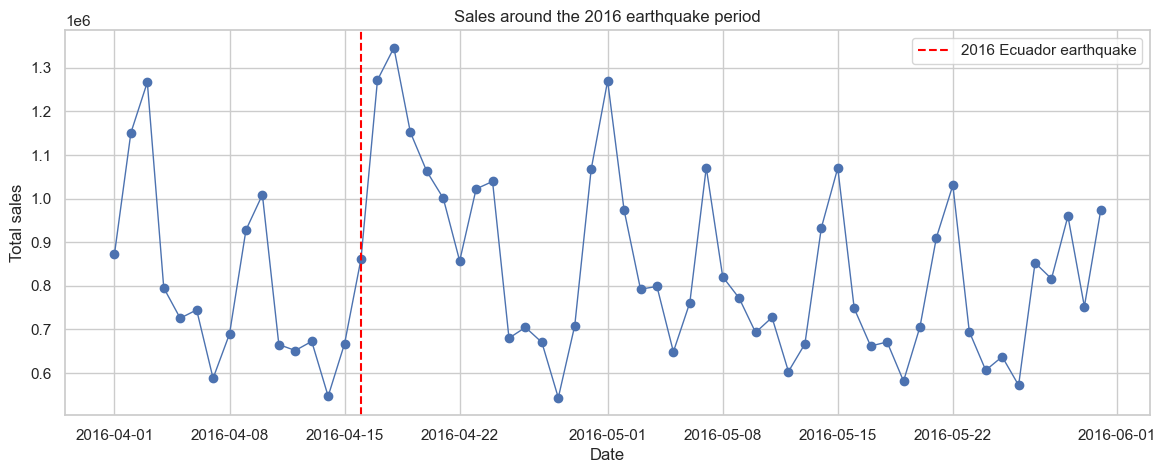

,earthquake_period,days,avg_sales,total_sales
0,before,15,798300.423981,1.197451e+07
1,during,15,932567.916150,1.398852e+07
2,after,31,799336.524523,2.477943e+07


In [29]:
earthquake_window = sales_daily.loc[
    sales_daily["date"].between("2016-04-01", "2016-05-31")
].copy()

earthquake_window["earthquake_period"] = pd.cut(
    earthquake_window["date"],
    bins=pd.to_datetime(["2016-03-31", "2016-04-15", "2016-04-30", "2016-05-31"]),
    labels=["before", "during", "after"],
)

earthquake_summary = (
    earthquake_window.groupby("earthquake_period", observed=True, as_index=False)
    .agg(days=("date", "nunique"), avg_sales=("total_sales", "mean"), total_sales=("total_sales", "sum"))
)

fig, ax = plt.subplots(figsize=(14, 5))
ax.plot(earthquake_window["date"], earthquake_window["total_sales"], marker="o", linewidth=1)
ax.axvline(pd.Timestamp("2016-04-16"), color="red", linestyle="--", label="2016 Ecuador earthquake")
ax.set_title("Sales around the 2016 earthquake period")
ax.set_xlabel("Date")
ax.set_ylabel("Total sales")
ax.legend()
plt.show()

earthquake_summary

In [30]:
holiday_dates = active_holidays.loc[active_holidays["locale"].eq("National"), ["date", "description"]].drop_duplicates()
major_holiday_dates = holiday_dates.loc[holiday_dates["date"].between("2013-01-01", "2017-08-15")].copy()

holiday_windows = []
for _, row in major_holiday_dates.iterrows():
    event_date = row["date"]
    window = sales_daily.loc[sales_daily["date"].between(event_date - pd.Timedelta(days=7), event_date + pd.Timedelta(days=7))].copy()
    if window.empty:
        continue
    window["holiday_date"] = event_date
    window["holiday_description"] = row["description"]
    window["relative_day"] = (window["date"] - event_date).dt.days
    window["holiday_window"] = np.select(
        [window["relative_day"].lt(0), window["relative_day"].eq(0), window["relative_day"].gt(0)],
        ["before", "during", "after"],
        default="outside_window",
    )
    holiday_windows.append(window)

holiday_window_sales = pd.concat(holiday_windows, ignore_index=True) if holiday_windows else pd.DataFrame()

holiday_comparison = (
    holiday_window_sales.groupby("holiday_window", as_index=False)
    .agg(days=("date", "nunique"), avg_total_sales=("total_sales", "mean"), median_total_sales=("total_sales", "median"))
    .sort_values("avg_total_sales", ascending=False)
)

holiday_comparison

,holiday_window,days,avg_total_sales,median_total_sales
2,during,131,758118.733295,746939.640160
1,before,436,724546.505628,706364.749001
0,after,440,712514.552775,716329.635071


In [31]:
holiday_type_summary = (
    holidays_clean.groupby(["locale", "type", "transferred", "is_active_holiday"], as_index=False)
    .agg(events=("description", "count"), unique_dates=("date", "nunique"))
    .sort_values(["locale", "type", "transferred"])
)

special_day_examples = holidays_clean.loc[
    holidays_clean["type"].isin(["Transfer", "Bridge", "Work Day"]),
    ["date", "type", "locale", "locale_name", "description", "transferred", "is_active_holiday"],
].sort_values("date")

holiday_type_summary, special_day_examples.head(20)

(      locale        type  transferred  is_active_holiday  events  unique_dates
 0      Local  Additional        False               True      11            11
 1      Local     Holiday        False               True     133           121
 2      Local     Holiday         True              False       4             4
 3      Local    Transfer        False               True       4             4
 4   National  Additional        False               True      40            40
 5   National      Bridge        False               True       5             5
 6   National       Event        False               True      56            55
 7   National     Holiday        False               True      52            52
 8   National     Holiday         True              False       8             8
 9   National    Transfer        False               True       8             8
 10  National    Work Day        False              False       5             5
 11  Regional     Holiday        False  

## 1.5 Missing value strategy

- [ ] Check missing oil price dates
- [ ] Decide oil imputation strategy
  - Forward fill
  - Backward fill
  - Interpolation
  - Combination approach
- [ ] Document why the strategy is leakage-safe
- [ ] Check missing values after all merges

### Oil imputation and post-merge missing values

In [32]:
full_oil_dates = pd.DataFrame(
    {"date": pd.date_range(train_base["date"].min(), test_base["date"].max(), freq="D")}
)

oil_daily = full_oil_dates.merge(oil, on="date", how="left")
oil_daily["missing_oil_price"] = oil_daily["dcoilwtico"].isna()

oil_missing_summary = pd.DataFrame(
    [
        {
            "date_start": oil_daily["date"].min(),
            "date_end": oil_daily["date"].max(),
            "total_days": len(oil_daily),
            "missing_oil_days": int(oil_daily["missing_oil_price"].sum()),
            "missing_pct": round(oil_daily["missing_oil_price"].mean() * 100, 2),
        }
    ]
)

oil_missing_summary

,date_start,date_end,total_days,missing_oil_days,missing_pct
0,2013-01-01,2017-08-31,1704,529,31.04


In [33]:
oil_daily["oil_ffill"] = oil_daily["dcoilwtico"].ffill()
oil_daily["oil_bfill"] = oil_daily["dcoilwtico"].bfill()
oil_daily["oil_interpolate"] = oil_daily["dcoilwtico"].interpolate(method="linear")

# Modeling default: forward-fill from the most recent known price, with backfill only for leading missing dates.
oil_daily["oil_price_imputed"] = oil_daily["oil_ffill"].fillna(oil_daily["oil_bfill"])
oil_daily["oil_was_missing"] = oil_daily["dcoilwtico"].isna()

oil_imputation_check = oil_daily[[
    "date",
    "dcoilwtico",
    "oil_ffill",
    "oil_bfill",
    "oil_interpolate",
    "oil_price_imputed",
    "oil_was_missing",
]].head(15)

oil_imputation_check

,date,dcoilwtico,oil_ffill,oil_bfill,oil_interpolate,oil_price_imputed,oil_was_missing
0,2013-01-01,NaN,NaN,93.14,NaN,93.14,True
1,2013-01-02,93.14,93.14,93.14,93.140000,93.14,False
2,2013-01-03,92.97,92.97,92.97,92.970000,92.97,False
3,2013-01-04,93.12,93.12,93.12,93.120000,93.12,False
4,2013-01-05,NaN,93.12,93.20,93.146667,93.12,True
5,2013-01-06,NaN,93.12,93.20,93.173333,93.12,True
6,2013-01-07,93.20,93.20,93.20,93.200000,93.20,False
7,2013-01-08,93.21,93.21,93.21,93.210000,93.21,False
8,2013-01-09,93.08,93.08,93.08,93.080000,93.08,False
9,2013-01-10,93.81,93.81,93.81,93.810000,93.81,False


### Oil imputation leakage note

The default modeling feature should use forward fill because it only carries the most recently observed oil price into later dates. Backfill is used only for leading missing values before the first available oil observation, where no prior value exists. Linear interpolation is useful for sensitivity analysis, but it uses both past and future prices, so it should not be the default production-style model input.

In [34]:
oil_model_features = oil_daily[["date", "oil_price_imputed", "oil_was_missing"]]

train_model_frame = (
    train_enriched.drop(columns=["dcoilwtico"], errors="ignore")
    .merge(oil_model_features, on="date", how="left", validate="many_to_one")
)

test_model_frame = (
    test_enriched.drop(columns=["dcoilwtico"], errors="ignore")
    .merge(oil_model_features, on="date", how="left", validate="many_to_one")
)

post_merge_missing = pd.concat(
    [
        train_model_frame.isna().sum().rename("train_missing"),
        test_model_frame.isna().sum().rename("test_missing"),
    ],
    axis=1,
).fillna(0).astype(int)

post_merge_missing = post_merge_missing.loc[post_merge_missing.sum(axis=1).gt(0)]
post_merge_missing

,train_missing,test_missing


## Phase deliverable

EDA section with plots, observations, and modeling implications.

## Done when

You can clearly explain the main sales patterns, data relationships, and missing value decisions.

#   Phase 2 — Strategic Feature Engineering

## Objective

Phase 2 converts the integrated Phase 1 tables into modeling-ready feature frames. The feature set is intentionally deterministic and reproducible: date-derived features come only from the calendar date, store and product features preserve the competition keys plus store metadata, oil features use the imputed daily oil series, and holiday features keep national, regional, and local signals separate so later models can decide how much each signal matters.

## 2.1 Deterministic date features

These features are safe for both train and test because they are fully determined by the `date` column. `is_payday` marks the 15th and the final calendar day of each month, matching the common salary-cycle hypothesis for retail demand.

In [35]:
def add_date_features(df: pd.DataFrame) -> pd.DataFrame:
    featured = df.copy()
    date = featured["date"]

    featured["year"] = date.dt.year.astype("int16")
    featured["month"] = date.dt.month.astype("int8")
    featured["day"] = date.dt.day.astype("int8")
    featured["dayofweek"] = date.dt.dayofweek.astype("int8")
    featured["weekofyear"] = date.dt.isocalendar().week.astype("int16")
    featured["quarter"] = date.dt.quarter.astype("int8")
    featured["is_weekend"] = date.dt.dayofweek.isin([5, 6])
    featured["is_month_start"] = date.dt.is_month_start
    featured["is_month_end"] = date.dt.is_month_end
    featured["is_payday"] = date.dt.day.eq(15) | date.dt.is_month_end
    return featured


train_features = add_date_features(train_model_frame)
test_features = add_date_features(test_model_frame)

date_feature_cols = [
    "year",
    "month",
    "day",
    "dayofweek",
    "weekofyear",
    "quarter",
    "is_weekend",
    "is_month_start",
    "is_month_end",
    "is_payday",
]

train_features[date_feature_cols].head()

,year,month,day,dayofweek,weekofyear,quarter,is_weekend,is_month_start,is_month_end,is_payday
0,2013,1,1,1,1,1,False,True,False,False
1,2013,1,1,1,1,1,False,True,False,False
2,2013,1,1,1,1,1,False,True,False,False
3,2013,1,1,1,1,1,False,True,False,False
4,2013,1,1,1,1,1,False,True,False,False


## 2.2 Store and product features

The core competition identifiers are preserved rather than ordinal-encoded in place. Tree models can consume integer `store_nbr` directly, while linear models and neural models can one-hot encode or embed `store_nbr`, `family`, and the metadata columns later in the modeling phase. Interaction columns are added as explicit categorical strings for store-product and metadata-product effects.

In [36]:
store_metadata_cols = ["city", "state", "type", "cluster"]
base_product_cols = ["store_nbr", "family", *store_metadata_cols]

missing_store_product_cols = [col for col in base_product_cols if col not in train_features.columns]
if missing_store_product_cols:
    raise KeyError(f"Missing expected store/product columns: {missing_store_product_cols}")


def add_store_product_features(df: pd.DataFrame) -> pd.DataFrame:
    featured = df.copy()
    store_text = featured["store_nbr"].astype("string")
    cluster_text = featured["cluster"].astype("string")
    family_text = featured["family"].astype("string")
    type_text = featured["type"].astype("string")

    featured["store_family"] = store_text + "_" + family_text
    featured["store_type_family"] = type_text + "_" + family_text
    featured["cluster_family"] = cluster_text + "_" + family_text
    return featured


train_features = add_store_product_features(train_features)
test_features = add_store_product_features(test_features)

store_product_feature_cols = [
    "store_nbr",
    "family",
    "city",
    "state",
    "type",
    "cluster",
    "store_family",
    "store_type_family",
    "cluster_family",
]

store_product_feature_audit = pd.DataFrame(
    [
        {
            "feature": col,
            "train_unique_values": train_features[col].nunique(dropna=False),
            "test_unique_values": test_features[col].nunique(dropna=False),
            "missing_train": int(train_features[col].isna().sum()),
            "missing_test": int(test_features[col].isna().sum()),
        }
        for col in store_product_feature_cols
    ]
)

store_product_feature_audit

,feature,train_unique_values,test_unique_values,missing_train,missing_test
0,store_nbr,54,54,0,0
1,family,33,33,0,0
2,city,22,22,0,0
3,state,16,16,0,0
4,type,5,5,0,0
5,cluster,17,17,0,0
6,store_family,1782,1782,0,0
7,store_type_family,165,165,0,0
8,cluster_family,561,561,0,0


## 2.3 Oil price features

The same imputed daily oil price from Phase 1 is retained, then expanded with lagged and rolling features. Lag and rolling features are shifted by one day so they summarize information available before the current sales date; this avoids accidentally using the current day's oil value inside a historical rolling statistic. Whether these features improve validation score should be tested in Phase 3 with the same validation splits used for the baseline.

In [37]:
oil_feature_source = oil_daily[["date", "oil_price_imputed", "oil_was_missing"]].copy()
oil_feature_source = oil_feature_source.sort_values("date")

for lag in [1, 7, 14, 28]:
    oil_feature_source[f"oil_price_lag_{lag}"] = oil_feature_source["oil_price_imputed"].shift(lag)

shifted_oil = oil_feature_source["oil_price_imputed"].shift(1)
for window in [7, 14, 28]:
    oil_feature_source[f"oil_price_roll_mean_{window}"] = shifted_oil.rolling(
        window=window,
        min_periods=1,
    ).mean()

oil_feature_source["oil_price_change_1"] = (
    oil_feature_source["oil_price_imputed"] - oil_feature_source["oil_price_lag_1"]
)

oil_feature_cols = [col for col in oil_feature_source.columns if col != "date"]

train_features = train_features.drop(columns=oil_feature_cols, errors="ignore").merge(
    oil_feature_source,
    on="date",
    how="left",
    validate="many_to_one",
)

test_features = test_features.drop(columns=oil_feature_cols, errors="ignore").merge(
    oil_feature_source,
    on="date",
    how="left",
    validate="many_to_one",
)

oil_feature_summary = pd.DataFrame(
    [
        {
            "feature": col,
            "missing_train": int(train_features[col].isna().sum()),
            "missing_test": int(test_features[col].isna().sum()),
            "train_min": train_features[col].min(),
            "train_max": train_features[col].max(),
        }
        for col in oil_feature_cols
    ]
)

oil_feature_summary

,feature,missing_train,missing_test,train_min,train_max
0,oil_price_imputed,0,0,26.19,110.62
1,oil_was_missing,0,0,False,True
2,oil_price_lag_1,1782,0,26.19,110.62
3,oil_price_lag_7,12474,0,26.19,110.62
4,oil_price_lag_14,24948,0,26.19,110.62
5,oil_price_lag_28,49896,0,26.19,110.62
6,oil_price_roll_mean_7,1782,0,28.424286,109.42
7,oil_price_roll_mean_14,1782,0,29.139286,108.975
8,oil_price_roll_mean_28,1782,0,30.21,108.076429
9,oil_price_change_1,1782,0,-7.76,4.12


### Oil validation note

Oil features are included in `train_features` and `test_features`, but they should be treated as candidates rather than assumed improvements. In Phase 3, compare validation RMSLE with and without `oil_price_imputed`, lag, rolling, and change features while keeping the same split and model settings. Keep them only if the validation score improves or if error analysis shows a consistent benefit for oil-sensitive product families.

## 2.4 Holiday features

Holiday signals are separated by scope: national holidays apply to every row on that date, regional holidays apply only when the store state matches `locale_name`, and local holidays apply only when the store city matches `locale_name`. Transferred holidays, bridge days, and work days are added as explicit flags because they can reverse or distort normal holiday demand patterns.

In [38]:
def normalize_event_group(description: str, event_type: str) -> str:
    text = str(description).lower()
    event_type = str(event_type).lower().replace(" ", "_")

    if "terremoto" in text or "earthquake" in text:
        return "earthquake"
    if "navidad" in text or "christmas" in text:
        return "christmas"
    if "primer dia" in text or "año nuevo" in text or "ano nuevo" in text:
        return "new_year"
    if "carnaval" in text:
        return "carnival"
    if "viernes santo" in text or "difuntos" in text:
        return "religious"
    if "independencia" in text or "batalla" in text or "fundacion" in text or "fundación" in text:
        return "civic"
    if "black friday" in text or "cyber monday" in text:
        return "commercial_event"
    if "futbol" in text or "fútbol" in text:
        return "sports_event"
    return event_type


holiday_scope_source = holidays_clean.copy()
holiday_scope_source["event_group"] = holiday_scope_source.apply(
    lambda row: normalize_event_group(row["description"], row["type"]),
    axis=1,
)
holiday_scope_source["is_active_holiday"] = (
    ~holiday_scope_source["transferred"] & ~holiday_scope_source["is_work_day"]
)


def join_unique(values: pd.Series) -> str:
    clean_values = sorted({str(value) for value in values if pd.notna(value) and str(value)})
    return "; ".join(clean_values)


def build_holiday_scope_features(locale: str, join_cols: list[str], prefix: str) -> pd.DataFrame:
    scoped = holiday_scope_source.loc[holiday_scope_source["locale"].eq(locale)].copy()
    if locale == "Regional":
        scoped = scoped.rename(columns={"locale_name": "state"})
    elif locale == "Local":
        scoped = scoped.rename(columns={"locale_name": "city"})

    return (
        scoped.groupby(join_cols, as_index=False)
        .agg(
            **{
                f"{prefix}_holiday_count": ("is_active_holiday", "sum"),
                f"{prefix}_transferred_count": ("transferred", "sum"),
                f"{prefix}_bridge_count": ("is_bridge", "sum"),
                f"{prefix}_work_day_count": ("is_work_day", "sum"),
                f"{prefix}_event_groups": ("event_group", join_unique),
            }
        )
    )


national_holiday_features = build_holiday_scope_features("National", ["date"], "national")
regional_holiday_features = build_holiday_scope_features("Regional", ["date", "state"], "regional")
local_holiday_features = build_holiday_scope_features("Local", ["date", "city"], "local")


def add_scope_holiday_features(df: pd.DataFrame) -> pd.DataFrame:
    featured = df.copy()
    holiday_cols_to_replace = [
        col
        for col in featured.columns
        if col.startswith(("national_", "regional_", "local_"))
        or col
        in {
            "is_holiday",
            "national_holiday",
            "regional_holiday",
            "local_holiday",
            "transferred_holiday",
            "bridge_day",
            "work_day",
            "holiday_event_group",
        }
    ]
    featured = featured.drop(columns=holiday_cols_to_replace, errors="ignore")

    featured = featured.merge(national_holiday_features, on="date", how="left", validate="many_to_one")
    featured = featured.merge(
        regional_holiday_features,
        on=["date", "state"],
        how="left",
        validate="many_to_one",
    )
    featured = featured.merge(
        local_holiday_features,
        on=["date", "city"],
        how="left",
        validate="many_to_one",
    )

    count_cols = [
        "national_holiday_count",
        "regional_holiday_count",
        "local_holiday_count",
        "national_transferred_count",
        "regional_transferred_count",
        "local_transferred_count",
        "national_bridge_count",
        "regional_bridge_count",
        "local_bridge_count",
        "national_work_day_count",
        "regional_work_day_count",
        "local_work_day_count",
    ]
    group_cols = ["national_event_groups", "regional_event_groups", "local_event_groups"]

    featured[count_cols] = featured[count_cols].fillna(0).astype("int16")
    featured[group_cols] = featured[group_cols].fillna("")

    featured["national_holiday"] = featured["national_holiday_count"].gt(0)
    featured["regional_holiday"] = featured["regional_holiday_count"].gt(0)
    featured["local_holiday"] = featured["local_holiday_count"].gt(0)
    featured["is_holiday"] = featured[["national_holiday", "regional_holiday", "local_holiday"]].any(axis=1)
    featured["transferred_holiday"] = featured[
        ["national_transferred_count", "regional_transferred_count", "local_transferred_count"]
    ].sum(axis=1).gt(0)
    featured["bridge_day"] = featured[
        ["national_bridge_count", "regional_bridge_count", "local_bridge_count"]
    ].sum(axis=1).gt(0)
    featured["work_day"] = featured[
        ["national_work_day_count", "regional_work_day_count", "local_work_day_count"]
    ].sum(axis=1).gt(0)

    event_group_lookup = featured[group_cols].drop_duplicates().copy()
    event_group_lookup["holiday_event_group"] = event_group_lookup.apply(
        lambda row: join_unique(pd.Series("; ".join(row).split("; "))),
        axis=1,
    )
    featured = featured.merge(
        event_group_lookup,
        on=group_cols,
        how="left",
        validate="many_to_one",
    )
    return featured


train_features = add_scope_holiday_features(train_features)
test_features = add_scope_holiday_features(test_features)

holiday_feature_cols = [
    "is_holiday",
    "national_holiday",
    "regional_holiday",
    "local_holiday",
    "transferred_holiday",
    "bridge_day",
    "work_day",
    "holiday_event_group",
]

holiday_feature_summary = pd.concat(
    [
        train_features[holiday_feature_cols].agg(["sum", "nunique"]).T.add_prefix("train_"),
        test_features[holiday_feature_cols].agg(["sum", "nunique"]).T.add_prefix("test_"),
    ],
    axis=1,
)

holiday_feature_summary

,train_sum,train_nunique,test_sum,test_nunique
is_holiday,245916,2,66,2
national_holiday,233442,2,0,1
regional_holiday,1023,2,0,1
local_holiday,11880,2,66,2
transferred_holiday,12837,2,0,1
bridge_day,5346,2,0,1
work_day,8910,2,0,1
holiday_event_group,new_yearnew_yearnew_yearnew_yearnew_yearnew_ye...,21,civicciviccivicciviccivicciviccivicciviccivicc...,2


### Holiday collision handling

Holiday collisions are handled by aggregation rather than row duplication. If several holiday records match the same store-date row, the notebook keeps one modeling row, sums the matching holiday counts by scope, joins unique event groups with semicolons, and sets each binary flag to `True` when at least one matching record exists. Active holiday flags exclude transferred holidays and work days; transferred holidays, bridge days, and work days remain available as separate features so the model can learn their distinct demand effects.

## 2.5 Lag features

Sales lag features must be generated from an explicit historical sales table. For final training, the history can be the full training set. For validation or test-style scoring, pass only the training-fold history that would have been known at prediction time. This prevents validation or test target values from leaking into features.

In [39]:
sales_history_key_cols = ["date", "store_nbr", "family"]
lag_days = [1, 7, 14, 28, 30]


def assert_required_columns(df: pd.DataFrame, required_cols: list[str], frame_name: str) -> None:
    missing_cols = [col for col in required_cols if col not in df.columns]
    if missing_cols:
        raise AssertionError(f"{frame_name} is missing required columns: {missing_cols}")


def assert_valid_sales_target(df: pd.DataFrame, target_col: str = "sales") -> None:
    if target_col not in df.columns:
        return
    if df[target_col].isna().any():
        raise AssertionError(f"{target_col} contains missing values.")
    if df[target_col].lt(0).any():
        raise AssertionError(f"{target_col} contains negative values.")


def prepare_sales_history(history_df: pd.DataFrame, target_col: str = "sales") -> pd.DataFrame:
    required_cols = [*sales_history_key_cols, target_col]
    assert_required_columns(history_df, required_cols, "history_df")
    assert_valid_sales_target(history_df, target_col)

    history = history_df[required_cols].copy()
    history["date"] = pd.to_datetime(history["date"])
    history = history.sort_values(sales_history_key_cols)

    duplicate_count = history.duplicated(sales_history_key_cols).sum()
    if duplicate_count:
        raise AssertionError(f"history_df contains {duplicate_count} duplicate store-family-date rows.")
    return history


def add_sales_lag_features(
    df: pd.DataFrame,
    history_df: pd.DataFrame,
    lags: list[int] = lag_days,
    target_col: str = "sales",
) -> pd.DataFrame:
    assert_required_columns(df, sales_history_key_cols, "feature frame")
    history = prepare_sales_history(history_df, target_col)
    featured = df.copy()

    for lag in lags:
        lag_frame = history.copy()
        lag_frame["date"] = lag_frame["date"] + pd.to_timedelta(lag, unit="D")
        lag_frame = lag_frame.rename(columns={target_col: f"sales_lag_{lag}"})
        featured = featured.merge(
            lag_frame[[*sales_history_key_cols, f"sales_lag_{lag}"]],
            on=sales_history_key_cols,
            how="left",
            validate="many_to_one",
        )
    return featured


train_features = add_sales_lag_features(train_features, train_base)
test_features = add_sales_lag_features(test_features, train_base)

lag_feature_cols = [f"sales_lag_{lag}" for lag in lag_days]

lag_feature_summary = pd.DataFrame(
    [
        {
            "feature": col,
            "missing_train": int(train_features[col].isna().sum()),
            "missing_test": int(test_features[col].isna().sum()),
            "train_min": train_features[col].min(),
            "train_max": train_features[col].max(),
        }
        for col in lag_feature_cols
    ]
)

lag_feature_summary

,feature,missing_train,missing_test,train_min,train_max
0,sales_lag_1,8910,26730,0.0,124717.0
1,sales_lag_7,19602,16038,0.0,124717.0
2,sales_lag_14,32076,3564,0.0,124717.0
3,sales_lag_28,57024,0,0.0,124717.0
4,sales_lag_30,60588,0,0.0,124717.0


### Manual lag validation

The check below samples a few rows and looks the lag value up directly in `train_base` at `date - lag`. The notebook compares the engineered feature to the historical target and reports whether each sampled value matches.

In [40]:
lag_validation_rows = []
validation_candidates = train_features.dropna(subset=["sales_lag_7"]).head(3)
train_sales_lookup = prepare_sales_history(train_base).set_index(sales_history_key_cols)["sales"]

for _, row in validation_candidates.iterrows():
    for lag in lag_days:
        lookup_key = (
            row["date"] - pd.to_timedelta(lag, unit="D"),
            row["store_nbr"],
            row["family"],
        )
        expected_value = train_sales_lookup.get(lookup_key, np.nan)
        actual_value = row[f"sales_lag_{lag}"]
        lag_validation_rows.append(
            {
                "date": row["date"],
                "store_nbr": row["store_nbr"],
                "family": row["family"],
                "lag": lag,
                "history_date": lookup_key[0],
                "expected_sales": expected_value,
                "engineered_lag": actual_value,
                "matches_history": bool(pd.isna(expected_value) and pd.isna(actual_value))
                or np.isclose(expected_value, actual_value, equal_nan=True),
            }
        )

manual_lag_validation = pd.DataFrame(lag_validation_rows)
manual_lag_validation

,date,store_nbr,family,lag,history_date,expected_sales,engineered_lag,matches_history
0,2013-01-08,1,AUTOMOTIVE,1,2013-01-07,0.0,0.0,True
1,2013-01-08,1,AUTOMOTIVE,7,2013-01-01,0.0,0.0,True
2,2013-01-08,1,AUTOMOTIVE,14,2012-12-25,NaN,NaN,True
3,2013-01-08,1,AUTOMOTIVE,28,2012-12-11,NaN,NaN,True
4,2013-01-08,1,AUTOMOTIVE,30,2012-12-09,NaN,NaN,True
5,2013-01-08,1,BABY CARE,1,2013-01-07,0.0,0.0,True
6,2013-01-08,1,BABY CARE,7,2013-01-01,0.0,0.0,True
7,2013-01-08,1,BABY CARE,14,2012-12-25,NaN,NaN,True
8,2013-01-08,1,BABY CARE,28,2012-12-11,NaN,NaN,True
9,2013-01-08,1,BABY CARE,30,2012-12-09,NaN,NaN,True


## 2.6 Rolling window statistics

Rolling sales statistics are computed within each `store_nbr` and `family` series. The target is shifted before the rolling calculation, so the current row's sales value is never included in its own features. For validation or test generation, pass only the historical sales data that should be visible at prediction time.

In [41]:
rolling_windows = [7, 14, 30]


def build_in_history_rolling_features(
    history_df: pd.DataFrame,
    windows: list[int] = rolling_windows,
    target_col: str = "sales",
) -> pd.DataFrame:
    history = prepare_sales_history(history_df, target_col)
    group_cols = ["store_nbr", "family"]
    history["_sales_shifted"] = history.groupby(group_cols)[target_col].shift(1)

    for window in windows:
        history[f"sales_roll_mean_{window}"] = history.groupby(group_cols)["_sales_shifted"].transform(
            lambda values: values.rolling(window=window, min_periods=1).mean()
        )
        history[f"sales_roll_std_{window}"] = history.groupby(group_cols)["_sales_shifted"].transform(
            lambda values: values.rolling(window=window, min_periods=2).std()
        )

    rolling_cols = [
        feature
        for window in windows
        for feature in [f"sales_roll_mean_{window}", f"sales_roll_std_{window}"]
    ]
    return history[[*sales_history_key_cols, *rolling_cols]]


def add_sales_rolling_features(
    df: pd.DataFrame,
    history_df: pd.DataFrame,
    windows: list[int] = rolling_windows,
    target_col: str = "sales",
) -> pd.DataFrame:
    assert_required_columns(df, sales_history_key_cols, "feature frame")
    rolling_frame = build_in_history_rolling_features(history_df, windows, target_col)
    rolling_cols = [col for col in rolling_frame.columns if col not in sales_history_key_cols]

    featured = df.drop(columns=rolling_cols, errors="ignore").merge(
        rolling_frame,
        on=sales_history_key_cols,
        how="left",
        validate="many_to_one",
        indicator="_rolling_source",
    )

    future_rows = featured["_rolling_source"].eq("left_only")
    if future_rows.any():
        history = prepare_sales_history(history_df, target_col)
        history_groups = {
            key: group.set_index("date")[target_col].sort_index()
            for key, group in history.groupby(["store_nbr", "family"], sort=False)
        }

        for row_idx, row in featured.loc[future_rows].iterrows():
            history_series = history_groups.get((row["store_nbr"], row["family"]))
            if history_series is None:
                continue

            prior_sales = history_series.loc[history_series.index < row["date"]]
            for window in windows:
                window_values = prior_sales.tail(window)
                featured.at[row_idx, f"sales_roll_mean_{window}"] = window_values.mean()
                featured.at[row_idx, f"sales_roll_std_{window}"] = window_values.std()

    featured = featured.drop(columns="_rolling_source")
    return featured


train_features = add_sales_rolling_features(train_features, train_base)
test_features = add_sales_rolling_features(test_features, train_base)

rolling_feature_cols = [
    feature
    for window in rolling_windows
    for feature in [f"sales_roll_mean_{window}", f"sales_roll_std_{window}"]
]

rolling_feature_summary = pd.DataFrame(
    [
        {
            "feature": col,
            "missing_train": int(train_features[col].isna().sum()),
            "missing_test": int(test_features[col].isna().sum()),
            "train_min": train_features[col].min(),
            "train_max": train_features[col].max(),
        }
        for col in rolling_feature_cols
    ]
)

rolling_feature_summary

,feature,missing_train,missing_test,train_min,train_max
0,sales_roll_mean_7,1782,0,0.0,29937.285714
1,sales_roll_std_7,3564,0,0.0,47275.358965
2,sales_roll_mean_14,1782,0,0.0,20097.642857
3,sales_roll_std_14,3564,0,0.0,34922.451434
4,sales_roll_mean_30,1782,0,0.0,15777.200000
5,sales_roll_std_30,3564,0,0.0,24289.054733


### Rolling validation note

Rolling features are candidate predictors, not guaranteed improvements. In Phase 3, compare validation RMSLE with and without the rolling means and standard deviations while using the same split, model, and encoding. For a strict holdout simulation, build validation rows with `history_df` limited to dates before the validation window.

## 2.7 Fourier features

Fourier terms represent cyclical time with smooth sine and cosine waves. Weekly terms help capture recurring day-of-week seasonality, while annual terms help capture smooth within-year seasonality without forcing the model to learn each date independently.

In [42]:
def add_fourier_features(
    df: pd.DataFrame,
    date_col: str = "date",
    weekly_order: int = 3,
    annual_order: int = 5,
) -> pd.DataFrame:
    assert_required_columns(df, [date_col], "feature frame")
    featured = df.copy()
    day_number = (featured[date_col] - featured[date_col].min()).dt.days.astype(float)

    fourier_specs = {"weekly": (7.0, weekly_order), "annual": (365.25, annual_order)}
    for cycle_name, (period, order) in fourier_specs.items():
        for harmonic in range(1, order + 1):
            angle = 2 * np.pi * harmonic * day_number / period
            featured[f"{cycle_name}_sin_{harmonic}"] = np.sin(angle)
            featured[f"{cycle_name}_cos_{harmonic}"] = np.cos(angle)
    return featured


train_features = add_fourier_features(train_features)
test_features = add_fourier_features(test_features)

fourier_feature_cols = [
    col
    for col in train_features.columns
    if col.startswith(("weekly_sin_", "weekly_cos_", "annual_sin_", "annual_cos_"))
]

fourier_feature_summary = pd.DataFrame(
    [
        {
            "feature": col,
            "train_min": train_features[col].min(),
            "train_max": train_features[col].max(),
            "test_min": test_features[col].min(),
            "test_max": test_features[col].max(),
        }
        for col in fourier_feature_cols
    ]
)

fourier_feature_summary.head(10)

,feature,train_min,train_max,test_min,test_max
0,weekly_sin_1,-0.974928,0.974928,-0.974928,0.974928
1,weekly_cos_1,-0.900969,1.000000,-0.900969,1.000000
2,weekly_sin_2,-0.974928,0.974928,-0.974928,0.974928
3,weekly_cos_2,-0.900969,1.000000,-0.900969,1.000000
4,weekly_sin_3,-0.974928,0.974928,-0.974928,0.974928
5,weekly_cos_3,-0.900969,1.000000,-0.900969,1.000000
6,annual_sin_1,-0.999999,0.999999,0.000000,0.255182
7,annual_cos_1,-0.999998,1.000000,0.966893,1.000000
8,annual_sin_2,-0.999999,0.999999,0.000000,0.493468
9,annual_cos_2,-0.999998,1.000000,0.869764,1.000000


### Fourier validation note

Fourier features are especially useful for models that do not naturally extrapolate smooth calendar cycles. In Phase 3, compare model performance with and without the weekly and annual Fourier terms. Keep them if they improve validation score or reduce seasonal residual structure.

## 2.8 Feature pipeline

The reusable pipeline below separates non-target features from target-history features. `create_train_feature_frame` can use the training target history for final model fitting. `create_test_feature_frame` uses the same logic but requires historical training sales and never reads a test target column.

In [43]:
def add_oil_features(df: pd.DataFrame, oil_features: pd.DataFrame = oil_feature_source) -> pd.DataFrame:
    return df.drop(columns=oil_feature_cols, errors="ignore").merge(
        oil_features,
        on="date",
        how="left",
        validate="many_to_one",
    )


def add_non_target_features(df: pd.DataFrame) -> pd.DataFrame:
    features = add_date_features(df)
    features = add_store_product_features(features)
    features = add_oil_features(features)
    features = add_scope_holiday_features(features)
    features = add_fourier_features(features)
    return features


def add_target_history_features(df: pd.DataFrame, history_df: pd.DataFrame) -> pd.DataFrame:
    features = add_sales_lag_features(df, history_df)
    features = add_sales_rolling_features(features, history_df)
    return features


def create_train_feature_frame(train_frame: pd.DataFrame, history_df: pd.DataFrame) -> pd.DataFrame:
    assert_required_columns(train_frame, [*sales_history_key_cols, "sales"], "train_frame")
    assert_valid_sales_target(train_frame)
    features = add_non_target_features(train_frame)
    features = add_target_history_features(features, history_df)
    return features


def create_test_feature_frame(test_frame: pd.DataFrame, train_history_df: pd.DataFrame) -> pd.DataFrame:
    assert_required_columns(test_frame, sales_history_key_cols, "test_frame")
    if "sales" in test_frame.columns:
        raise AssertionError("test_frame must not contain a sales target column.")
    features = add_non_target_features(test_frame)
    features = add_target_history_features(features, train_history_df)
    return features


required_modeling_features = [
    *date_feature_cols,
    *store_product_feature_cols,
    *oil_feature_cols,
    *holiday_feature_cols,
    *lag_feature_cols,
    *rolling_feature_cols,
    *fourier_feature_cols,
]

assert_required_columns(train_features, required_modeling_features, "train_features")
assert_required_columns(test_features, required_modeling_features, "test_features")
assert_valid_sales_target(train_features)

pipeline_smoke_train = create_train_feature_frame(train_model_frame.head(2_000), train_base.head(20_000))
pipeline_smoke_test = create_test_feature_frame(test_model_frame.head(500), train_base.tail(100_000))

pipeline_checks = pd.DataFrame(
    [
        {
            "check": "train_features_required_columns",
            "passed": set(required_modeling_features).issubset(train_features.columns),
        },
        {
            "check": "test_features_required_columns",
            "passed": set(required_modeling_features).issubset(test_features.columns),
        },
        {
            "check": "train_target_non_negative",
            "passed": bool(train_features["sales"].ge(0).all()),
        },
        {
            "check": "test_pipeline_has_no_target",
            "passed": "sales" not in pipeline_smoke_test.columns,
        },
        {
            "check": "pipeline_smoke_train_rows",
            "passed": len(pipeline_smoke_train) == 2_000,
        },
        {
            "check": "pipeline_smoke_test_rows",
            "passed": len(pipeline_smoke_test) == 500,
        },
    ]
)

pipeline_checks

,check,passed
0,train_features_required_columns,True
1,test_features_required_columns,True
2,train_target_non_negative,True
3,test_pipeline_has_no_target,True
4,pipeline_smoke_train_rows,True
5,pipeline_smoke_test_rows,True


## Phase 2 deliverable

`train_features` and `test_features` are the Phase 2 modeling frames. They include deterministic calendar features, preserved store/product identifiers and metadata, interaction categories, imputed oil price features, scoped holiday flags, leakage-safe lag and rolling sales features, and Fourier seasonality terms. The reusable pipeline functions can apply the same logic to train, validation, and test frames as long as the caller passes only the sales history that should be visible at prediction time.

In [44]:
phase_2_feature_groups = {
    "date_features": date_feature_cols,
    "store_product_features": store_product_feature_cols,
    "oil_features": oil_feature_cols,
    "holiday_features": holiday_feature_cols,
    "lag_features": lag_feature_cols,
    "rolling_features": rolling_feature_cols,
    "fourier_features": fourier_feature_cols,
}

phase_2_audit = pd.DataFrame(
    [
        {
            "feature_group": group_name,
            "feature_count": len(columns),
            "features": ", ".join(columns),
        }
        for group_name, columns in phase_2_feature_groups.items()
    ]
)

phase_2_shape_summary = pd.DataFrame(
    [
        {"dataset": "train_features", "rows": len(train_features), "columns": train_features.shape[1]},
        {"dataset": "test_features", "rows": len(test_features), "columns": test_features.shape[1]},
    ]
)

leakage_safety_summary = pd.DataFrame(
    [
        {
            "rule": "Lag features use explicit historical sales only",
            "status": "implemented via add_sales_lag_features(df, history_df)",
        },
        {
            "rule": "Rolling features are shifted before calculation",
            "status": "implemented via grouped sales.shift(1)",
        },
        {
            "rule": "Test features do not read test target values",
            "status": "implemented via create_test_feature_frame assertions",
        },
        {
            "rule": "Validation features can avoid validation targets",
            "status": "pass training-fold history_df when generating validation rows",
        },
    ]
)

display(phase_2_audit)
display(phase_2_shape_summary)
display(leakage_safety_summary)

,feature_group,feature_count,features
0,date_features,10,"year, month, day, dayofweek, weekofyear, quart..."
1,store_product_features,9,"store_nbr, family, city, state, type, cluster,..."
2,oil_features,10,"oil_price_imputed, oil_was_missing, oil_price_..."
3,holiday_features,8,"is_holiday, national_holiday, regional_holiday..."
4,lag_features,5,"sales_lag_1, sales_lag_7, sales_lag_14, sales_..."
5,rolling_features,6,"sales_roll_mean_7, sales_roll_std_7, sales_rol..."
6,fourier_features,16,"weekly_sin_1, weekly_cos_1, weekly_sin_2, week..."


,dataset,rows,columns
0,train_features,3000888,84
1,test_features,28512,83


,rule,status
0,Lag features use explicit historical sales only,"implemented via add_sales_lag_features(df, his..."
1,Rolling features are shifted before calculation,implemented via grouped sales.shift(1)
2,Test features do not read test target values,implemented via create_test_feature_frame asse...
3,Validation features can avoid validation targets,pass training-fold history_df when generating ...


#   Phase 3 — Model Selection & Validation Strategy

## Objective

Phase 3 turns the feature frames into a reliable modeling setup. The first priority is time-aware validation: validation rows must happen after training rows, and target-derived features for validation must be generated only from sales history that would have been known at prediction time.

## 3.1 Validation design

The holdout split uses the final block of training dates as validation. The validation horizon is matched to the test horizon when possible, so the offline score better reflects the competition forecast task. Random K-fold is invalid for this time series problem because it would mix future dates into training folds, letting the model learn from demand patterns that occur after the rows it is asked to validate.

In [49]:
validation_horizon_days = int(data["test"]["date"].nunique())
validation_end_date = train_base["date"].max()
validation_start_date = validation_end_date - pd.Timedelta(days=validation_horizon_days - 1)

holdout_train_mask = train_base["date"].lt(validation_start_date)
holdout_valid_mask = train_base["date"].between(validation_start_date, validation_end_date)

holdout_train_raw = train_base.loc[holdout_train_mask].copy()
holdout_valid_raw = train_base.loc[holdout_valid_mask].copy()

holdout_train_features = train_features.loc[train_features["date"].lt(validation_start_date)].copy()
holdout_valid_features = train_features.loc[
    train_features["date"].between(validation_start_date, validation_end_date)
].copy()

# Rebuild validation target-history features with only pre-validation sales history.
target_history_feature_cols = lag_feature_cols + rolling_feature_cols
holdout_valid_features = holdout_valid_features.drop(
    columns=target_history_feature_cols,
    errors="ignore",
)
holdout_valid_features = add_target_history_features(holdout_valid_features, holdout_train_raw)

assert holdout_train_raw["date"].max() < holdout_valid_raw["date"].min()
assert holdout_train_features["date"].max() < holdout_valid_features["date"].min()
assert len(holdout_valid_raw) == len(holdout_valid_features)
assert_valid_sales_target(holdout_train_raw)
assert_valid_sales_target(holdout_valid_raw)

validation_design = pd.DataFrame(
    [
        {
            "split": "holdout_train",
            "start_date": holdout_train_raw["date"].min(),
            "end_date": holdout_train_raw["date"].max(),
            "unique_dates": holdout_train_raw["date"].nunique(),
            "rows": len(holdout_train_raw),
        },
        {
            "split": "holdout_validation",
            "start_date": holdout_valid_raw["date"].min(),
            "end_date": holdout_valid_raw["date"].max(),
            "unique_dates": holdout_valid_raw["date"].nunique(),
            "rows": len(holdout_valid_raw),
        },
    ]
)

validation_design

,split,start_date,end_date,unique_dates,rows
0,holdout_train,2013-01-01,2017-07-30,1668,2972376
1,holdout_validation,2017-07-31,2017-08-15,16,28512


### Expanding-window and sliding-window folds

The holdout split is the main validation split. The helper below can also create multiple time-aware folds. Expanding windows keep the training start fixed and move the validation window forward; sliding windows keep a fixed-length training window before each validation period.

In [50]:
def make_time_series_folds(
    df: pd.DataFrame,
    date_col: str = "date",
    horizon_days: int = validation_horizon_days,
    n_splits: int = 3,
    mode: str = "expanding",
    train_window_days: int | None = None,
) -> pd.DataFrame:
    if mode not in {"expanding", "sliding"}:
        raise ValueError("mode must be either 'expanding' or 'sliding'.")
    if mode == "sliding" and train_window_days is None:
        raise ValueError("train_window_days is required for sliding-window folds.")

    unique_dates = pd.Series(pd.to_datetime(df[date_col].drop_duplicates())).sort_values().reset_index(drop=True)
    min_date = unique_dates.min()
    max_date = unique_dates.max()
    folds = []

    for split_id in range(n_splits):
        valid_end = max_date - pd.Timedelta(days=split_id * horizon_days)
        valid_start = valid_end - pd.Timedelta(days=horizon_days - 1)
        train_end = valid_start - pd.Timedelta(days=1)

        if train_end < min_date:
            continue

        if mode == "sliding":
            train_start = max(min_date, train_end - pd.Timedelta(days=train_window_days - 1))
        else:
            train_start = min_date

        if train_start > train_end:
            continue

        folds.append(
            {
                "fold": n_splits - split_id,
                "mode": mode,
                "train_start": train_start,
                "train_end": train_end,
                "valid_start": valid_start,
                "valid_end": valid_end,
                "train_dates": int(unique_dates.between(train_start, train_end).sum()),
                "valid_dates": int(unique_dates.between(valid_start, valid_end).sum()),
            }
        )

    fold_table = pd.DataFrame(folds).sort_values(["valid_start"]).reset_index(drop=True)
    if not fold_table.empty:
        assert (fold_table["train_end"] < fold_table["valid_start"]).all()
    return fold_table


expanding_window_folds = make_time_series_folds(
    train_base,
    horizon_days=validation_horizon_days,
    n_splits=3,
    mode="expanding",
)

sliding_window_folds = make_time_series_folds(
    train_base,
    horizon_days=validation_horizon_days,
    n_splits=3,
    mode="sliding",
    train_window_days=365,
)

display(expanding_window_folds)
display(sliding_window_folds)

,fold,mode,train_start,train_end,valid_start,valid_end,train_dates,valid_dates
0,1,expanding,2013-01-01,2017-06-28,2017-06-29,2017-07-14,1636,16
1,2,expanding,2013-01-01,2017-07-14,2017-07-15,2017-07-30,1652,16
2,3,expanding,2013-01-01,2017-07-30,2017-07-31,2017-08-15,1668,16


,fold,mode,train_start,train_end,valid_start,valid_end,train_dates,valid_dates
0,1,sliding,2016-06-29,2017-06-28,2017-06-29,2017-07-14,364,16
1,2,sliding,2016-07-15,2017-07-14,2017-07-15,2017-07-30,364,16
2,3,sliding,2016-07-31,2017-07-30,2017-07-31,2017-08-15,364,16


## 3.2 Metric implementation

The competition metric is RMSLE. Predictions are clipped at zero before scoring because negative unit sales are invalid and `log1p` is undefined for values below `-1`. The custom implementation below is compared with scikit-learn's `mean_squared_log_error` when it is available.

In [51]:
def rmsle(y_true, y_pred, clip_predictions: bool = True) -> float:
    y_true = np.asarray(y_true, dtype=float)
    y_pred = np.asarray(y_pred, dtype=float)

    if np.isnan(y_true).any():
        raise ValueError("y_true contains NaN values.")
    if (y_true < 0).any():
        raise ValueError("RMSLE requires non-negative target values.")
    if clip_predictions:
        y_pred = np.clip(y_pred, 0, None)
    if (y_pred < 0).any():
        raise ValueError("RMSLE requires non-negative predictions. Use clip_predictions=True.")

    return float(np.sqrt(np.mean(np.square(np.log1p(y_pred) - np.log1p(y_true)))))


validation_global_mean = holdout_train_raw["sales"].mean()
validation_baseline_pred = (
    holdout_valid_features["sales_lag_7"]
    .fillna(holdout_valid_features["sales_roll_mean_30"])
    .fillna(validation_global_mean)
)

custom_rmsle = rmsle(holdout_valid_features["sales"], validation_baseline_pred)

try:
    from sklearn.metrics import mean_squared_log_error

    library_rmsle = float(
        np.sqrt(
            mean_squared_log_error(
                holdout_valid_features["sales"],
                np.clip(validation_baseline_pred, 0, None),
            )
        )
    )
    metric_comparison_note = "custom and sklearn metrics available"
except Exception as exc:
    library_rmsle = np.nan
    metric_comparison_note = f"sklearn comparison unavailable: {exc}"

metric_comparison = pd.DataFrame(
    [
        {
            "custom_rmsle": custom_rmsle,
            "library_rmsle": library_rmsle,
            "absolute_difference": abs(custom_rmsle - library_rmsle)
            if pd.notna(library_rmsle)
            else np.nan,
            "note": metric_comparison_note,
        }
    ]
)

metric_comparison

,custom_rmsle,library_rmsle,absolute_difference,note
0,0.568113,0.568113,0.0,custom and sklearn metrics available


### Experiment tracking table

Every validation run should be appended to a simple experiment table with the model name, feature set, validation period, RMSLE, and notes. This keeps baseline, gradient boosting, and later refinement experiments comparable.

In [52]:
experiment_columns = ["model", "feature_set", "validation_period", "rmsle", "notes"]
experiment_log = pd.DataFrame(columns=experiment_columns)


def log_experiment(
    experiment_log: pd.DataFrame,
    model: str,
    feature_set: str,
    validation_start,
    validation_end,
    score: float,
    notes: str = "",
) -> pd.DataFrame:
    row = pd.DataFrame(
        [
            {
                "model": model,
                "feature_set": feature_set,
                "validation_period": f"{pd.Timestamp(validation_start).date()} to {pd.Timestamp(validation_end).date()}",
                "rmsle": score,
                "notes": notes,
            }
        ],
        columns=experiment_columns,
    )
    if experiment_log.empty:
        return row
    return pd.concat([experiment_log, row], ignore_index=True)


experiment_log = log_experiment(
    experiment_log,
    model="Naive lag/rolling baseline",
    feature_set="sales_lag_7 + sales_roll_mean_30 fallback",
    validation_start=validation_start_date,
    validation_end=validation_end_date,
    score=custom_rmsle,
    notes="Validation target-history features use only dates before the holdout window.",
)

experiment_log

,model,feature_set,validation_period,rmsle,notes
0,Naive lag/rolling baseline,sales_lag_7 + sales_roll_mean_30 fallback,2017-07-31 to 2017-08-15,0.568113,Validation target-history features use only da...


## 3.3 Baseline model

Baselines set the minimum bar for later gradient boosting. The first group uses only historical sales summaries available before the validation window; the deterministic model adds simple trend and seasonal calendar terms.

In [53]:
y_valid = holdout_valid_features["sales"]
validation_period = f"{validation_start_date.date()} to {validation_end_date.date()}"
global_sales_mean = holdout_train_raw["sales"].mean()

store_family_mean_lookup = (
    holdout_train_raw.groupby(["store_nbr", "family"], as_index=False)["sales"]
    .mean()
    .rename(columns={"sales": "store_family_mean_sales"})
)
family_mean_lookup = (
    holdout_train_raw.groupby("family", as_index=False)["sales"]
    .mean()
    .rename(columns={"sales": "family_mean_sales"})
)

validation_average_features = holdout_valid_features.merge(
    store_family_mean_lookup,
    on=["store_nbr", "family"],
    how="left",
).merge(family_mean_lookup, on="family", how="left")

baseline_predictions = pd.DataFrame(
    {
        "previous_week_sales": holdout_valid_features["sales_lag_7"].fillna(global_sales_mean),
        "moving_average_30d": holdout_valid_features["sales_roll_mean_30"].fillna(global_sales_mean),
        "store_family_average": validation_average_features["store_family_mean_sales"]
        .fillna(validation_average_features["family_mean_sales"])
        .fillna(global_sales_mean),
    }
)

baseline_scores = pd.DataFrame(
    [
        {
            "model": "Previous week sales",
            "feature_set": "sales_lag_7",
            "validation_period": validation_period,
            "rmsle": rmsle(y_valid, baseline_predictions["previous_week_sales"]),
            "notes": "Seasonal naive baseline using the same store-family value from seven days earlier.",
        },
        {
            "model": "30-day moving average",
            "feature_set": "sales_roll_mean_30",
            "validation_period": validation_period,
            "rmsle": rmsle(y_valid, baseline_predictions["moving_average_30d"]),
            "notes": "Smooths noisy daily demand with only pre-validation history.",
        },
        {
            "model": "Store-family average",
            "feature_set": "store_nbr + family historical mean",
            "validation_period": validation_period,
            "rmsle": rmsle(y_valid, baseline_predictions["store_family_average"]),
            "notes": "Captures long-run level differences across stores and product families.",
        },
    ]
)

baseline_scores.sort_values("rmsle")

,model,feature_set,validation_period,rmsle,notes
1,30-day moving average,sales_roll_mean_30,2017-07-31 to 2017-08-15,0.526988,Smooths noisy daily demand with only pre-valid...
2,Store-family average,store_nbr + family historical mean,2017-07-31 to 2017-08-15,0.694527,Captures long-run level differences across sto...
0,Previous week sales,sales_lag_7,2017-07-31 to 2017-08-15,2.569649,Seasonal naive baseline using the same store-f...


### Deterministic trend and seasonality baseline

This Ridge model is still a baseline: it uses deterministic calendar structure, promotion counts, and store-family identity, but no future target information.

In [54]:
def add_deterministic_time_features(df: pd.DataFrame, origin_date) -> pd.DataFrame:
    featured = df.copy()
    featured["date"] = pd.to_datetime(featured["date"])
    featured["trend_days"] = (featured["date"] - pd.Timestamp(origin_date)).dt.days
    featured["day_of_week"] = featured["date"].dt.dayofweek
    featured["day_of_month"] = featured["date"].dt.day
    featured["month"] = featured["date"].dt.month
    featured["is_weekend"] = featured["day_of_week"].isin([5, 6]).astype(int)
    featured["weekly_sin"] = np.sin(2 * np.pi * featured["day_of_week"] / 7)
    featured["weekly_cos"] = np.cos(2 * np.pi * featured["day_of_week"] / 7)
    featured["annual_sin"] = np.sin(2 * np.pi * featured["date"].dt.dayofyear / 365.25)
    featured["annual_cos"] = np.cos(2 * np.pi * featured["date"].dt.dayofyear / 365.25)
    return featured


deterministic_train = add_deterministic_time_features(
    holdout_train_features,
    origin_date=holdout_train_features["date"].min(),
)
deterministic_valid = add_deterministic_time_features(
    holdout_valid_features,
    origin_date=holdout_train_features["date"].min(),
)

deterministic_numeric_cols = [
    "trend_days",
    "day_of_week",
    "day_of_month",
    "month",
    "is_weekend",
    "weekly_sin",
    "weekly_cos",
    "annual_sin",
    "annual_cos",
    "onpromotion",
]
deterministic_categorical_cols = ["store_nbr", "family"]
deterministic_feature_cols = deterministic_numeric_cols + deterministic_categorical_cols

try:
    from sklearn.compose import ColumnTransformer
    from sklearn.impute import SimpleImputer
    from sklearn.linear_model import Ridge
    from sklearn.pipeline import Pipeline
    from sklearn.preprocessing import OneHotEncoder, StandardScaler

    deterministic_preprocessor = ColumnTransformer(
        transformers=[
            (
                "numeric",
                Pipeline(
                    steps=[
                        ("imputer", SimpleImputer(strategy="median")),
                        ("scaler", StandardScaler()),
                    ]
                ),
                deterministic_numeric_cols,
            ),
            (
                "categorical",
                OneHotEncoder(handle_unknown="ignore"),
                deterministic_categorical_cols,
            ),
        ]
    )
    deterministic_model = Pipeline(
        steps=[
            ("preprocess", deterministic_preprocessor),
            ("model", Ridge(alpha=10.0)),
        ]
    )
    deterministic_model.fit(
        deterministic_train[deterministic_feature_cols],
        np.log1p(deterministic_train["sales"]),
    )
    deterministic_pred = np.expm1(
        deterministic_model.predict(deterministic_valid[deterministic_feature_cols])
    )
    deterministic_note = "Ridge on log1p sales with trend, weekly/annual seasonality, promotion, store, and family."
except Exception as exc:
    deterministic_pred = np.repeat(global_sales_mean, len(deterministic_valid))
    deterministic_note = f"Ridge baseline unavailable; used global mean fallback. Reason: {exc}"

deterministic_score = rmsle(y_valid, deterministic_pred)
deterministic_result = pd.DataFrame(
    [
        {
            "model": "Ridge trend-seasonality baseline",
            "feature_set": "trend + calendar seasonality + promotion + store/family",
            "validation_period": validation_period,
            "rmsle": deterministic_score,
            "notes": deterministic_note,
        }
    ]
)

deterministic_result

,model,feature_set,validation_period,rmsle,notes
0,Ridge trend-seasonality baseline,trend + calendar seasonality + promotion + sto...,2017-07-31 to 2017-08-15,1.080926,"Ridge on log1p sales with trend, weekly/annual..."


### Baseline takeaways

These scores show whether recency, smoothing, long-run store-family level, or deterministic calendar structure is the strongest simple signal. Gradient boosting should beat the best baseline while preserving the same time-aware validation rules.

In [55]:
experiment_log = pd.concat(
    [
        experiment_log,
        baseline_scores,
        deterministic_result,
    ],
    ignore_index=True,
).drop_duplicates(subset=["model", "feature_set", "validation_period"], keep="last")

experiment_log.sort_values("rmsle").reset_index(drop=True)

,model,feature_set,validation_period,rmsle,notes
0,30-day moving average,sales_roll_mean_30,2017-07-31 to 2017-08-15,0.526988,Smooths noisy daily demand with only pre-valid...
1,Naive lag/rolling baseline,sales_lag_7 + sales_roll_mean_30 fallback,2017-07-31 to 2017-08-15,0.568113,Validation target-history features use only da...
2,Store-family average,store_nbr + family historical mean,2017-07-31 to 2017-08-15,0.694527,Captures long-run level differences across sto...
3,Ridge trend-seasonality baseline,trend + calendar seasonality + promotion + sto...,2017-07-31 to 2017-08-15,1.080926,"Ridge on log1p sales with trend, weekly/annual..."
4,Previous week sales,sales_lag_7,2017-07-31 to 2017-08-15,2.569649,Seasonal naive baseline using the same store-f...


## 3.4 Gradient boosting models

Gradient boosting is the first strong model family. The code below trains LightGBM when available, then trains XGBoost or CatBoost when available, while recording RMSLE, runtime, approximate memory, categorical strategy, and feature set.

In [56]:
import gc
import json
import time
import tracemalloc


def memory_usage_mb(*frames: pd.DataFrame) -> float:
    return float(sum(frame.memory_usage(deep=True).sum() for frame in frames) / 1024**2)


def model_feature_columns(df: pd.DataFrame, feature_set: str = "full") -> list[str]:
    excluded_cols = {"id", "date", "sales"}
    full_cols = [col for col in df.columns if col not in excluded_cols]
    compact_patterns = (
        "store_nbr",
        "family",
        "onpromotion",
        "oil_price_imputed",
        "oil_was_missing",
        "sales_lag_",
        "sales_roll_",
        "day_",
        "week_",
        "month",
        "year",
        "is_",
        "holiday",
        "payday",
    )
    if feature_set == "compact":
        return [col for col in full_cols if col.startswith(compact_patterns) or col in {"city", "state", "type", "cluster"}]
    if feature_set == "full":
        return full_cols
    raise ValueError("feature_set must be 'compact' or 'full'.")


def split_feature_types(df: pd.DataFrame, feature_cols: list[str]) -> tuple[list[str], list[str]]:
    categorical_cols = [
        col for col in feature_cols
        if df[col].dtype == "object" or str(df[col].dtype).startswith("category")
    ]
    numeric_cols = [col for col in feature_cols if col not in categorical_cols]
    return numeric_cols, categorical_cols


def prepare_lgbm_matrix(df: pd.DataFrame, feature_cols: list[str], categorical_cols: list[str]) -> pd.DataFrame:
    matrix = df[feature_cols].copy()
    for col in categorical_cols:
        matrix[col] = matrix[col].astype("category")
    bool_cols = matrix.select_dtypes(include="bool").columns
    matrix[bool_cols] = matrix[bool_cols].astype(int)
    return matrix


boosting_feature_sets = {
    "compact": model_feature_columns(holdout_train_features, "compact"),
    "full": model_feature_columns(holdout_train_features, "full"),
}

boosting_feature_summary = pd.DataFrame(
    [
        {
            "feature_set": name,
            "features": len(cols),
            "categorical_features": len(split_feature_types(holdout_train_features, cols)[1]),
            "memory_mb_train_valid": memory_usage_mb(holdout_train_features[cols], holdout_valid_features[cols]),
        }
        for name, cols in boosting_feature_sets.items()
    ]
)

boosting_feature_summary

,feature_set,features,categorical_features,memory_mb_train_valid
0,compact,28,5,1174.029625
1,full,81,8,2783.429277


In [57]:
boosting_results = []
trained_boosting_models = {}


def record_boosting_result(
    model_name: str,
    feature_set: str,
    rmsle_score: float | None,
    train_seconds: float | None,
    memory_mb: float | None,
    categorical_strategy: str,
    parameters: dict,
    notes: str,
) -> None:
    boosting_results.append(
        {
            "model": model_name,
            "feature_set": feature_set,
            "validation_period": validation_period,
            "rmsle": rmsle_score,
            "train_seconds": train_seconds,
            "memory_mb": memory_mb,
            "categorical_strategy": categorical_strategy,
            "parameters": parameters,
            "notes": notes,
        }
    )


def timed_fit_predict(model_key: str, fit_fn, predict_fn):
    gc.collect()
    tracemalloc.start()
    start = time.perf_counter()
    model = fit_fn()
    train_seconds = time.perf_counter() - start
    _, peak = tracemalloc.get_traced_memory()
    tracemalloc.stop()
    predictions = predict_fn(model)
    trained_boosting_models[model_key] = model
    return predictions, train_seconds, peak / 1024**2


def train_lightgbm(feature_set: str = "compact") -> None:
    feature_cols = boosting_feature_sets[feature_set]
    _, categorical_cols = split_feature_types(holdout_train_features, feature_cols)
    X_train = prepare_lgbm_matrix(holdout_train_features, feature_cols, categorical_cols)
    X_valid = prepare_lgbm_matrix(holdout_valid_features, feature_cols, categorical_cols)
    y_train_log = np.log1p(holdout_train_features["sales"])

    params = {
        "objective": "regression",
        "learning_rate": 0.05,
        "n_estimators": 800,
        "num_leaves": 63,
        "subsample": 0.8,
        "colsample_bytree": 0.8,
        "reg_lambda": 1.0,
        "random_state": 42,
        "n_jobs": -1,
    }
    try:
        from lightgbm import LGBMRegressor, early_stopping, log_evaluation

        def fit_fn():
            model = LGBMRegressor(**params)
            model.fit(
                X_train,
                y_train_log,
                eval_set=[(X_valid, np.log1p(y_valid))],
                categorical_feature=categorical_cols,
                callbacks=[early_stopping(50), log_evaluation(0)],
            )
            return model

        predictions, train_seconds, peak_mb = timed_fit_predict(
            f"LightGBM::{feature_set}",
            fit_fn,
            lambda model: np.expm1(model.predict(X_valid)),
        )
        record_boosting_result(
            "LightGBM",
            feature_set,
            rmsle(y_valid, predictions),
            train_seconds,
            memory_usage_mb(X_train, X_valid) + peak_mb,
            "native category dtype",
            params,
            "Early stopping on holdout validation.",
        )
    except Exception as exc:
        record_boosting_result(
            "LightGBM",
            feature_set,
            None,
            None,
            memory_usage_mb(X_train, X_valid),
            "native category dtype",
            params,
            f"Skipped or failed: {exc}",
        )


train_lightgbm("compact")
train_lightgbm("full")

pd.DataFrame(boosting_results)

[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.099873 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 3465
[LightGBM] [Info] Number of data points in the train set: 2972376, number of used features: 28
[LightGBM] [Info] Start training from score 2.919643
Training until validation scores don't improve for 50 rounds
Early stopping, best iteration is:
[58]	valid_0's l2: 0.90843


,model,feature_set,validation_period,rmsle,train_seconds,memory_mb,categorical_strategy,parameters,notes
0,LightGBM,compact,2017-07-31 to 2017-08-15,0.953116,17.346138,1184.33051,native category dtype,"{'objective': 'regression', 'learning_rate': 0...",Early stopping on holdout validation.
1,LightGBM,full,2017-07-31 to 2017-08-15,NaN,NaN,1861.64366,native category dtype,"{'objective': 'regression', 'learning_rate': 0...","Skipped or failed: pandas dtypes must be int, ..."


In [58]:
def train_xgboost_or_catboost(feature_set: str = "compact") -> None:
    feature_cols = boosting_feature_sets[feature_set]
    numeric_cols, categorical_cols = split_feature_types(holdout_train_features, feature_cols)
    y_train_log = np.log1p(holdout_train_features["sales"])

    try:
        from sklearn.compose import ColumnTransformer
        from sklearn.impute import SimpleImputer
        from sklearn.pipeline import Pipeline
        from sklearn.preprocessing import OrdinalEncoder
        from xgboost import XGBRegressor

        params = {
            "objective": "reg:squarederror",
            "learning_rate": 0.05,
            "n_estimators": 700,
            "max_depth": 8,
            "subsample": 0.8,
            "colsample_bytree": 0.8,
            "reg_lambda": 1.0,
            "random_state": 42,
            "n_jobs": -1,
        }
        preprocessor = ColumnTransformer(
            transformers=[
                ("numeric", SimpleImputer(strategy="median"), numeric_cols),
                (
                    "categorical",
                    OrdinalEncoder(handle_unknown="use_encoded_value", unknown_value=-1),
                    categorical_cols,
                ),
            ],
            remainder="drop",
        )
        pipeline = Pipeline(
            steps=[
                ("preprocess", preprocessor),
                ("model", XGBRegressor(**params)),
            ]
        )

        X_train = holdout_train_features[feature_cols]
        X_valid = holdout_valid_features[feature_cols]
        predictions, train_seconds, peak_mb = timed_fit_predict(
            f"XGBoost::{feature_set}",
            lambda: pipeline.fit(X_train, y_train_log),
            lambda model: np.expm1(model.predict(X_valid)),
        )
        record_boosting_result(
            "XGBoost",
            feature_set,
            rmsle(y_valid, predictions),
            train_seconds,
            memory_usage_mb(X_train, X_valid) + peak_mb,
            "ordinal encoded categoricals",
            params,
            "Pipeline uses ordinal encoding to keep categorical handling explicit.",
        )
        return
    except Exception as xgb_exc:
        xgboost_error = xgb_exc

    try:
        from catboost import CatBoostRegressor

        params = {
            "loss_function": "RMSE",
            "learning_rate": 0.05,
            "iterations": 700,
            "depth": 8,
            "l2_leaf_reg": 3.0,
            "random_seed": 42,
            "verbose": False,
        }
        X_train = holdout_train_features[feature_cols].copy()
        X_valid = holdout_valid_features[feature_cols].copy()
        for col in categorical_cols:
            X_train[col] = X_train[col].astype(str).fillna("missing")
            X_valid[col] = X_valid[col].astype(str).fillna("missing")

        predictions, train_seconds, peak_mb = timed_fit_predict(
            f"CatBoost::{feature_set}",
            lambda: CatBoostRegressor(**params).fit(
                X_train,
                y_train_log,
                cat_features=categorical_cols,
                eval_set=(X_valid, np.log1p(y_valid)),
                early_stopping_rounds=50,
            ),
            lambda model: np.expm1(model.predict(X_valid)),
        )
        record_boosting_result(
            "CatBoost",
            feature_set,
            rmsle(y_valid, predictions),
            train_seconds,
            memory_usage_mb(X_train, X_valid) + peak_mb,
            "native cat_features",
            params,
            "Used because XGBoost was unavailable or failed.",
        )
    except Exception as cat_exc:
        record_boosting_result(
            "XGBoost/CatBoost",
            feature_set,
            None,
            None,
            memory_usage_mb(holdout_train_features[feature_cols], holdout_valid_features[feature_cols]),
            "ordinal or native categorical",
            {},
            f"Skipped or failed. XGBoost: {xgboost_error}; CatBoost: {cat_exc}",
        )


train_xgboost_or_catboost("compact")

boosting_results_table = pd.DataFrame(boosting_results)
boosting_results_table.sort_values("rmsle", na_position="last")

,model,feature_set,validation_period,rmsle,train_seconds,memory_mb,categorical_strategy,parameters,notes
2,XGBoost,compact,2017-07-31 to 2017-08-15,0.935862,183.902129,4519.288623,ordinal encoded categoricals,"{'objective': 'reg:squarederror', 'learning_ra...",Pipeline uses ordinal encoding to keep categor...
0,LightGBM,compact,2017-07-31 to 2017-08-15,0.953116,17.346138,1184.330510,native category dtype,"{'objective': 'regression', 'learning_rate': 0...",Early stopping on holdout validation.
1,LightGBM,full,2017-07-31 to 2017-08-15,NaN,NaN,1861.643660,native category dtype,"{'objective': 'regression', 'learning_rate': 0...","Skipped or failed: pandas dtypes must be int, ..."


### Categorical and feature-set strategy

The compact feature set is faster and easier to inspect. The full set gives boosting models more holiday, oil, store, lag, rolling, and interaction signals. LightGBM uses native categorical handling; XGBoost uses ordinal encoding in a pipeline; CatBoost uses native `cat_features` when it is the available second booster.

## 3.5 Hyperparameter tuning

Use a small manual search first. It is transparent, cheap enough for a notebook, and gives a reliable starting point before heavier random search or Optuna.

In [59]:
manual_lgbm_search_space = [
    {
        "learning_rate": 0.03,
        "n_estimators": 1200,
        "num_leaves": 31,
        "subsample": 0.8,
        "colsample_bytree": 0.8,
        "reg_lambda": 1.0,
    },
    {
        "learning_rate": 0.05,
        "n_estimators": 900,
        "num_leaves": 63,
        "subsample": 0.8,
        "colsample_bytree": 0.8,
        "reg_lambda": 2.0,
    },
    {
        "learning_rate": 0.08,
        "n_estimators": 700,
        "num_leaves": 95,
        "subsample": 0.9,
        "colsample_bytree": 0.9,
        "reg_lambda": 5.0,
    },
]

tuning_results = []
best_model_key = None

try:
    from lightgbm import LGBMRegressor, early_stopping, log_evaluation

    tuning_feature_set = "compact"
    tuning_feature_cols = boosting_feature_sets[tuning_feature_set]
    _, tuning_categorical_cols = split_feature_types(holdout_train_features, tuning_feature_cols)
    X_train_tune = prepare_lgbm_matrix(holdout_train_features, tuning_feature_cols, tuning_categorical_cols)
    X_valid_tune = prepare_lgbm_matrix(holdout_valid_features, tuning_feature_cols, tuning_categorical_cols)
    y_train_log = np.log1p(holdout_train_features["sales"])
    y_valid_log = np.log1p(y_valid)

    for trial_id, params in enumerate(manual_lgbm_search_space, start=1):
        trial_params = {
            **params,
            "objective": "regression",
            "random_state": 42,
            "n_jobs": -1,
        }
        gc.collect()
        start = time.perf_counter()
        model = LGBMRegressor(**trial_params)
        model.fit(
            X_train_tune,
            y_train_log,
            eval_set=[(X_valid_tune, y_valid_log)],
            categorical_feature=tuning_categorical_cols,
            callbacks=[early_stopping(50), log_evaluation(0)],
        )
        train_seconds = time.perf_counter() - start
        predictions = np.expm1(model.predict(X_valid_tune))
        score = rmsle(y_valid, predictions)
        model_key = f"LightGBM tuned trial {trial_id}"
        trained_boosting_models[model_key] = model
        tuning_results.append(
            {
                "trial": trial_id,
                "model": "LightGBM tuned",
                "feature_set": tuning_feature_set,
                "validation_period": validation_period,
                "rmsle": score,
                "train_seconds": train_seconds,
                "parameters": trial_params,
                "notes": "Manual search with early stopping.",
                "model_key": model_key,
            }
        )

    best_tuning_row = min(tuning_results, key=lambda row: row["rmsle"])
    best_model_key = best_tuning_row["model_key"]
except Exception as exc:
    tuning_results.append(
        {
            "trial": None,
            "model": "LightGBM tuned",
            "feature_set": "compact",
            "validation_period": validation_period,
            "rmsle": None,
            "train_seconds": None,
            "parameters": {},
            "notes": f"Manual tuning skipped or failed: {exc}",
            "model_key": None,
        }
    )

tuning_results_table = pd.DataFrame(tuning_results)
tuning_results_table.sort_values("rmsle", na_position="last")

[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.092887 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 3465
[LightGBM] [Info] Number of data points in the train set: 2972376, number of used features: 28
[LightGBM] [Info] Start training from score 2.919643
Training until validation scores don't improve for 50 rounds
Early stopping, best iteration is:
[65]	valid_0's l2: 1.22617
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.100008 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 3465
[LightGBM] [Info] Number of data points in the train set: 2972376, number of used features: 28
[LightGBM] [Info] Start training from score 2.919643
Training until validation scores don't improve for 50 rounds


,trial,model,feature_set,validation_period,rmsle,train_seconds,parameters,notes,model_key
2,3,LightGBM tuned,compact,2017-07-31 to 2017-08-15,0.722754,11.834954,"{'learning_rate': 0.08, 'n_estimators': 700, '...",Manual search with early stopping.,LightGBM tuned trial 3
1,2,LightGBM tuned,compact,2017-07-31 to 2017-08-15,0.966622,14.734716,"{'learning_rate': 0.05, 'n_estimators': 900, '...",Manual search with early stopping.,LightGBM tuned trial 2
0,1,LightGBM tuned,compact,2017-07-31 to 2017-08-15,1.107327,13.752587,"{'learning_rate': 0.03, 'n_estimators': 1200, ...",Manual search with early stopping.,LightGBM tuned trial 1


### Save best model configuration

The best configuration is saved as JSON so the final training and submission step can reuse the selected model settings without reading notebook prose.

In [60]:
model_selection_candidates = pd.concat(
    [
        boosting_results_table.assign(source="initial_boosting"),
        tuning_results_table.drop(columns=["trial", "model_key"], errors="ignore").assign(source="manual_tuning"),
    ],
    ignore_index=True,
)
scored_model_candidates = model_selection_candidates.dropna(subset=["rmsle"]).copy()

if not scored_model_candidates.empty:
    best_model_row = scored_model_candidates.sort_values("rmsle").iloc[0].to_dict()
else:
    best_model_row = {
        "model": "No boosting model trained",
        "feature_set": None,
        "validation_period": validation_period,
        "rmsle": None,
        "parameters": {},
        "notes": "Install lightgbm, xgboost, or catboost to train boosting models.",
    }

best_model_config = {
    "selected_at": pd.Timestamp.now().isoformat(),
    "validation_period": validation_period,
    "model": best_model_row.get("model"),
    "feature_set": best_model_row.get("feature_set"),
    "rmsle": None if pd.isna(best_model_row.get("rmsle")) else float(best_model_row.get("rmsle")),
    "parameters": best_model_row.get("parameters", {}),
    "notes": best_model_row.get("notes", ""),
}

model_config_path = PROJECT_ROOT / "outputs" / "models" / "best_model_config.json"
model_config_path.parent.mkdir(parents=True, exist_ok=True)
with model_config_path.open("w", encoding="utf-8") as file:
    json.dump(best_model_config, file, indent=2, default=str)

best_model_config

{'selected_at': '2026-05-18T18:42:03.429541',
 'validation_period': '2017-07-31 to 2017-08-15',
 'model': 'LightGBM tuned',
 'feature_set': 'compact',
 'rmsle': 0.7227535552938563,
 'parameters': {'learning_rate': 0.08,
  'n_estimators': 700,
  'num_leaves': 95,
  'subsample': 0.9,
  'colsample_bytree': 0.9,
  'reg_lambda': 5.0,
  'objective': 'regression',
  'random_state': 42,
  'n_jobs': -1},
 'notes': 'Manual search with early stopping.'}

## 3.6 Model comparison table

The final table combines baselines, initial boosting models, and tuning trials. The best validation RMSLE is highlighted with a rank of 1, but speed, interpretability, and complexity still matter for the final choice.

In [61]:
boosting_experiment_log = model_selection_candidates.rename(
    columns={"train_seconds": "speed_seconds"}
)[["model", "feature_set", "validation_period", "rmsle", "notes", "speed_seconds", "source"]]

baseline_comparison = experiment_log.copy()
baseline_comparison["speed_seconds"] = np.nan
baseline_comparison["source"] = "baseline"

final_experiment_table = pd.concat(
    [baseline_comparison, boosting_experiment_log],
    ignore_index=True,
    sort=False,
)
final_experiment_table["rank"] = final_experiment_table["rmsle"].rank(method="min")
final_experiment_table["is_best"] = final_experiment_table["rank"].eq(1)
final_experiment_table["tradeoff_summary"] = np.select(
    [
        final_experiment_table["source"].eq("baseline"),
        final_experiment_table["model"].str.contains("LightGBM", na=False),
        final_experiment_table["model"].str.contains("XGBoost|CatBoost", na=False),
    ],
    [
        "Most interpretable and fastest, but usually lower ceiling.",
        "Strong score/speed balance with native categorical support.",
        "Strong alternative booster, usually more complex to tune here.",
    ],
    default="Useful comparison point.",
)

final_experiment_table.sort_values(["rank", "source", "model"], na_position="last").reset_index(drop=True)

,model,feature_set,validation_period,rmsle,notes,speed_seconds,source,rank,is_best,tradeoff_summary
0,30-day moving average,sales_roll_mean_30,2017-07-31 to 2017-08-15,0.526988,Smooths noisy daily demand with only pre-valid...,NaN,baseline,1.0,True,"Most interpretable and fastest, but usually lo..."
1,Naive lag/rolling baseline,sales_lag_7 + sales_roll_mean_30 fallback,2017-07-31 to 2017-08-15,0.568113,Validation target-history features use only da...,NaN,baseline,2.0,False,"Most interpretable and fastest, but usually lo..."
2,Store-family average,store_nbr + family historical mean,2017-07-31 to 2017-08-15,0.694527,Captures long-run level differences across sto...,NaN,baseline,3.0,False,"Most interpretable and fastest, but usually lo..."
3,LightGBM tuned,compact,2017-07-31 to 2017-08-15,0.722754,Manual search with early stopping.,11.834954,manual_tuning,4.0,False,Strong score/speed balance with native categor...
4,XGBoost,compact,2017-07-31 to 2017-08-15,0.935862,Pipeline uses ordinal encoding to keep categor...,183.902129,initial_boosting,5.0,False,"Strong alternative booster, usually more compl..."
5,LightGBM,compact,2017-07-31 to 2017-08-15,0.953116,Early stopping on holdout validation.,17.346138,initial_boosting,6.0,False,Strong score/speed balance with native categor...
6,LightGBM tuned,compact,2017-07-31 to 2017-08-15,0.966622,Manual search with early stopping.,14.734716,manual_tuning,7.0,False,Strong score/speed balance with native categor...
7,Ridge trend-seasonality baseline,trend + calendar seasonality + promotion + sto...,2017-07-31 to 2017-08-15,1.080926,"Ridge on log1p sales with trend, weekly/annual...",NaN,baseline,8.0,False,"Most interpretable and fastest, but usually lo..."
8,LightGBM tuned,compact,2017-07-31 to 2017-08-15,1.107327,Manual search with early stopping.,13.752587,manual_tuning,9.0,False,Strong score/speed balance with native categor...
9,Previous week sales,sales_lag_7,2017-07-31 to 2017-08-15,2.569649,Seasonal naive baseline using the same store-f...,NaN,baseline,10.0,False,"Most interpretable and fastest, but usually lo..."


### Model selection decision

Choose the rank-1 model when it materially beats the baselines and has acceptable training time. If two models are close, prefer the simpler or faster one for the first submission, then revisit the more complex model during refinement.

In [62]:
if final_experiment_table["rmsle"].notna().any():
    selected_model_summary = (
        final_experiment_table.dropna(subset=["rmsle"])
        .sort_values("rmsle")
        .head(1)
        .assign(
            selection_reason=lambda df: (
                "Best validation RMSLE on the time-aware holdout; compare speed and complexity before final retraining."
            )
        )
    )
else:
    selected_model_summary = pd.DataFrame(
        [
            {
                "model": "No validated boosting model yet",
                "selection_reason": "Install boosting dependencies and rerun Phase 3.4-3.5.",
            }
        ]
    )

selected_model_summary

,model,feature_set,validation_period,rmsle,notes,speed_seconds,source,rank,is_best,tradeoff_summary,selection_reason
2,30-day moving average,sales_roll_mean_30,2017-07-31 to 2017-08-15,0.526988,Smooths noisy daily demand with only pre-valid...,NaN,baseline,1.0,True,"Most interpretable and fastest, but usually lo...",Best validation RMSLE on the time-aware holdou...


#   Phase 4 — Error Analysis & Refinement

#   Phase 5 — Submission & Portfolio Documentation

#   Phase 6 — Attention or Transformer Experiment